In [1]:
!pip -q install sacrebleu nltk sentencepiece


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 9.6 MB/s eta 0:00:00


In [2]:
import os
import re
import math
import time
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sacrebleu

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import (
    pad_sequence,
    pack_padded_sequence,
    pad_packed_sequence
)

from tqdm.auto import tqdm

# Running on Kaggle
# all its outputs under /kaggle/working/.

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)
print("PyTorch:", torch.__version__)

Device: cuda
PyTorch: 2.10.0+cu128


In [3]:
ARABIC_DIACRITICS = re.compile(
    r'[\u064B-\u065F\u0670\u06D6-\u06ED]'
)


def normalize_arabic(text):

    text = text.strip()

    text = ARABIC_DIACRITICS.sub('', text)

    text = text.replace('أ', 'ا')
    text = text.replace('إ', 'ا')
    text = text.replace('آ', 'ا')
    text = text.replace('ى', 'ي')
    text = text.replace('ة', 'ه')
    text = text.replace('ـ', '')

    text = re.sub(
        r'([.!?؟،,])',
        r' \1 ',
        text
    )

    text = re.sub(r'\s+', ' ', text).strip()

    return text


def normalize_english(text):

    text = text.lower().strip()

    text = re.sub(
        r"([.!?,])",
        r' \1 ',
        text
    )

    text = re.sub(
        r"[^a-z0-9.!?,'\s]",
        '',
        text
    )

    text = re.sub(r'\s+', ' ', text).strip()

    return text


def tokenize(text):
    return text.split()

In [4]:
!pip install -q opustools

import subprocess

SRC_LANG = "ar"
TGT_LANG = "en"
CORPORA = ["Wikipedia", "Tatoeba"]

for corpus in CORPORA:
    print(f"--- Downloading {corpus} ({SRC_LANG}-{TGT_LANG}) ---")
    subprocess.run([
        "opus_read",
        "-d", corpus,
        "-s", SRC_LANG,
        "-t", TGT_LANG,
        "-w", f"{corpus.lower()}_{SRC_LANG}.txt", f"{corpus.lower()}_{TGT_LANG}.txt",
        "-wm", "moses",
        "-q"
    ])


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 64.4 MB/s eta 0:00:00:00:0100:01
--- Downloading Wikipedia (ar-en) ---
No alignment file "/projappl/nlpl/data/OPUS/Wikipedia/latest/xml/ar-en.xml.gz" or "./Wikipedia_latest_xml_ar-en.xml.gz" found
The following files are available for downloading:

   1 MB https://object.pouta.csc.fi/OPUS-Wikipedia/v1.0/xml/ar-en.xml.gz | 1 documents, 151136 alignment pairs, 3162547 source tokens, 3509577 target tokens (id 581570)
 156 MB https://object.pouta.csc.fi/OPUS-Wikipedia/v1.0/xml/ar.zip | 3 documents, 974851 sentences, 24909466 tokens (id 581717)
   4 GB https://object.pouta.csc.fi/OPUS-Wikipedia/v1.0/xml/en.zip | 39 documents, 10736187 sentences, 275815008 tokens (id 581742)

   4 GB Total size
./Wikipedia_latest_xml_ar-en.xml.gz ... 100% of 1 MB
./Wikipedia_latest_xml_ar.zip ... 100% of 156 MB
./Wikipedia_latest_xml_en.zip ... 100% of 4 GB

Parsing file "./Wikipedia_latest_xml_ar-en.xml.gz" ... 61.19%
Parsing file "Wikipedia/xml/ar/wiki0.ar-en.xml" ... 100.0%
Parsing file "Wikipedia/xml/en/wiki0.ar-en.xml" ... 100.0%
Parsing file "./Wikipedia_latest_xml_ar-en.xml.gz" ... 100.0%






--- Downloading Tatoeba (ar-en) ---
No alignment file "/projappl/nlpl/data/OPUS/Tatoeba/latest/xml/ar-en.xml.gz" or "./Tatoeba_latest_xml_ar-en.xml.gz" found
The following files are available for downloading:

 300 KB https://object.pouta.csc.fi/OPUS-Tatoeba/v2026-07-08/xml/ar-en.xml.gz | 8 documents, 32505 alignment pairs, 187802 source tokens, 232660 target tokens (id 698082)
   3 MB https://object.pouta.csc.fi/OPUS-Tatoeba/v2026-07-08/xml/ar.zip | 8 documents, 69205 sentences, 383713 tokens (id 705206)
 167 MB https://object.pouta.csc.fi/OPUS-Tatoeba/v2026-07-08/xml/en.zip | 8 documents, 2156239 sentences, 19442773 tokens (id 705581)

 171 MB Total size
./Tatoeba_latest_xml_ar-en.xml.gz ... 100% of 300 KB
./Tatoeba_latest_xml_ar.zip ... 100% of 3 MB
./Tatoeba_latest_xml_en.zip ... 100% of 167 MB

Parsing file "./Tatoeba_latest_xml_ar-en.xml.gz" ... 0.0%
Parsing file "Tatoeba/xml/ar/2019-07-10.xml" ... 100.0%
Parsing file "Tatoeba/xml/en/2019-07-10.xml" ... 99.86%
ng chunk ... 100.0%
Parsing file "Tatoeba/xml/ar/2020-05-31.xml" ... 99.94%
Parsing file "Tatoeba/xml/en/2020-05-31.xml" ... 99.47%
ng chunk ... 100.0%
Parsing file "Tatoeba/xml/ar/2020-11-09.xml" ... 97.08%
Parsing file "Tatoeba/xml/en/2020-11-09.xml" ... 87.87%
ng chunk ... 100.0%
Parsing file "Tatoeba/xml/ar/2021-03-09.xml" ... 100.0%
Parsing file "Tatoeba/xml/en/2021-03-09.xml" ... 94.65%
Parsing file "./Tatoeba_latest_xml_ar-en.xml.gz" ... 85.36%
Parsing file "Tatoeba/xml/ar/2021-07-22.xml" ... 99.27%
Parsing file "Tatoeba/xml/en/2021-07-22.xml" ... 98.33%
ng chunk ... 100.0%
Parsing file "Tatoeba/xml/ar/2022-03-03.xml" ... 100.0%
Parsing file "Tatoeba/xml/en/2022-03-03.xml" ... 99.37%
ng chunk ... 100.0%
Parsing file "Tatoeba/xml/ar/2023-04-12.xml" ... 99.98%
Parsing file "Tatoeba/xml/en/2023-04-12.xml" ... 97.98

Parsing file "Tatoeba/xml/en/2026-07-08.xml" ... 99.77%
Parsing file "./Tatoeba_latest_xml_ar-en.xml.gz" ... 100.0%





In [5]:
LATIN_LETTERS_RE = re.compile(r'[A-Za-z]')
ARABIC_LETTERS_RE = re.compile(r'[\u0600-\u06FF]')

def load_pairs_from_opus(en_path, ar_path):
    pairs = []
    skipped_empty = 0
    skipped_mixed = 0

    with open(en_path, "r", encoding="utf-8") as f_en, \
         open(ar_path, "r", encoding="utf-8") as f_ar:

        for en_line, ar_line in zip(f_en, f_ar):
            en_raw = en_line.strip()
            ar_raw = ar_line.strip()

            if not en_raw or not ar_raw:
                skipped_empty += 1
                continue

            # Drop code-mixed pairs: Latin letters on the AR side / Arabic letters on the EN side
            if LATIN_LETTERS_RE.search(ar_raw) or ARABIC_LETTERS_RE.search(en_raw):
                skipped_mixed += 1
                continue

            en = normalize_english(en_raw)
            ar = normalize_arabic(ar_raw)

            if ar and en:
                pairs.append((ar, en))

    print(f"Skipped {skipped_empty:,} empty pairs")
    print(f"Skipped {skipped_mixed:,} code-mixed pairs")

    return pairs


def dedupe(pairs):
    seen = set()
    deduped = []
    for ar, en in pairs:
        key = (ar, en)
        if key not in seen:
            seen.add(key)
            deduped.append((ar, en))
    return deduped, len(pairs) - len(deduped)


print("=== Wikipedia ===")
wiki_pairs = load_pairs_from_opus("wikipedia_en.txt", "wikipedia_ar.txt")
wiki_pairs, wiki_dups = dedupe(wiki_pairs)
print(f"Wikipedia pairs after cleaning + dedup: {len(wiki_pairs):,} (removed {wiki_dups:,} duplicates)")

print("\n=== Tatoeba ===")
tatoeba_pairs = load_pairs_from_opus("tatoeba_en.txt", "tatoeba_ar.txt")
tatoeba_pairs, tatoeba_dups = dedupe(tatoeba_pairs)
print(f"Tatoeba pairs after cleaning + dedup: {len(tatoeba_pairs):,} (removed {tatoeba_dups:,} duplicates)")

# A pair that exists in both corpora would otherwise get duplicated once the two lists are combined below
cross_seen = set(wiki_pairs)
before = len(tatoeba_pairs)
tatoeba_pairs = [p for p in tatoeba_pairs if p not in cross_seen]
print(f"Removed {before - len(tatoeba_pairs):,} Tatoeba pairs also present in Wikipedia")

print("\nExamples (Wikipedia):")
for ar, en in wiki_pairs[:2]:
    print("AR :", ar)
    print("EN :", en)
    print()

print("Examples (Tatoeba):")
for ar, en in tatoeba_pairs[:2]:
    print("AR :", ar)
    print("EN :", en)
    print()


=== Wikipedia ===
Skipped 0 empty pairs
Skipped 62,761 code-mixed pairs
Wikipedia pairs after cleaning + dedup: 86,270 (removed 2,096 duplicates)

=== Tatoeba ===
Skipped 0 empty pairs
Skipped 22 code-mixed pairs
Tatoeba pairs after cleaning + dedup: 32,393 (removed 90 duplicates)
Removed 1 Tatoeba pairs also present in Wikipedia

Examples (Wikipedia):
AR : يحدها من الشمال خليج فنلندا ، ومن الغرب بحر البلطيق ، ومن الجنوب لاتفيا ( 343 كم ) ، والي الشرق من بحيره بيبوس والاتحاد الروسي ( 338 . 6 كم ) .
EN : it is bordered to the north by the gulf of finland , to the west by the baltic sea , to the south by latvia 343 km , and to the east by lake peipus and russia 338 . 6 km .

AR : وعبر بحر البلطيق تقع السويد في الغرب وفنلندا في الشمال .
EN : across the baltic sea lies sweden in the west and finland in the north .

Examples (Tatoeba):
AR : لنجرب فعل شيء ما .
EN : let 's try something .

AR : لنجرب شيئا !
EN : let 's try something .



In [6]:
def iqr_bounds(values, k=1.5):
    q1, q3 = np.percentile(values, [25, 75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr


MIN_WORDS = 1
MAX_WORDS = 35
MAX_EN_AR_RATIO = 2.5


def remove_length_outliers(pairs, name, min_words=MIN_WORDS, max_words=MAX_WORDS,
                            max_ratio=MAX_EN_AR_RATIO):
    """Remove outlier (ar, en) pairs from `pairs` based on sentence length
    and on the EN/AR length ratio, and print a short report.

    Two layers of filtering are applied, in order:
      1. Hard caps         -> min_words <= len <= max_words (both sides),
                               en_len / ar_len <= max_ratio
      2. IQR-based bounds   -> statistical outlier bounds on the average
                               sentence length and on the EN/AR ratio,
                               clipped so they never exceed the hard caps.
    """
    n_start = len(pairs)
    if n_start == 0:
        print(f"[{name}] No pairs to filter.")
        return pairs

    # --- 1) Hard length cap on both sides -----------------------------
    ar_lens = np.array([len(tokenize(ar)) for ar, en in pairs])
    en_lens = np.array([len(tokenize(en)) for ar, en in pairs])

    hard_cap_keep = (
        (ar_lens >= min_words) & (ar_lens <= max_words) &
        (en_lens >= min_words) & (en_lens <= max_words)
    )
    pairs = [p for p, keep in zip(pairs, hard_cap_keep) if keep]
    removed = n_start - len(pairs)
    print(f"[{name}] Hard cap ({min_words}-{max_words} words/side): "
          f"removed {removed:,} / {n_start:,} ({removed / n_start:.1%})")

    # --- 2) IQR outliers on average sentence length --------------------
    n_before = len(pairs)
    ar_lens = np.array([len(tokenize(ar)) for ar, en in pairs])
    en_lens = np.array([len(tokenize(en)) for ar, en in pairs])
    avg_lens = (ar_lens + en_lens) / 2

    low, high = iqr_bounds(avg_lens)
    low = max(low, min_words)
    high = min(high, max_words)

    keep_mask = (avg_lens >= low) & (avg_lens <= high)
    pairs = [p for p, keep in zip(pairs, keep_mask) if keep]
    removed = n_before - len(pairs)
    print(f"[{name}] Avg length IQR bounds [{low:.1f}, {high:.1f}]: "
          f"removed {removed:,} / {n_before:,} ({removed / n_before:.1%})")

    # --- 3) EN/AR ratio outliers, hard-capped at max_ratio --------------
    n_before = len(pairs)
    ar_lens = np.array([len(tokenize(ar)) for ar, en in pairs])
    en_lens = np.array([len(tokenize(en)) for ar, en in pairs])
    ratio = en_lens / ar_lens

    low_r, high_r = iqr_bounds(ratio)
    high_r = min(high_r, max_ratio)

    keep_mask = (ratio >= low_r) & (ratio <= high_r)
    pairs = [p for p, keep in zip(pairs, keep_mask) if keep]
    removed = n_before - len(pairs)
    print(f"[{name}] EN/AR ratio bounds [{low_r:.2f}, {high_r:.2f}] (hard cap {max_ratio}): "
          f"removed {removed:,} / {n_before:,} ({removed / n_before:.1%})")

    total_removed = n_start - len(pairs)
    print(f"[{name}] TOTAL removed: {total_removed:,} / {n_start:,} ({total_removed / n_start:.1%})  "
          f"-> Remaining: {len(pairs):,}\n")

    return pairs


print("=== Removing outliers: Tatoeba ===")
tatoeba_pairs = remove_length_outliers(tatoeba_pairs, "Tatoeba")

print("=== Removing outliers: Wikipedia ===")
wiki_pairs = remove_length_outliers(wiki_pairs, "Wikipedia")


=== Removing outliers: Tatoeba ===
[Tatoeba] Hard cap (1-35 words/side): removed 122 / 32,392 (0.4%)
[Tatoeba] Avg length IQR bounds [1.0, 12.0]: removed 1,312 / 32,270 (4.1%)
[Tatoeba] EN/AR ratio bounds [0.25, 2.25] (hard cap 2.5): removed 389 / 30,958 (1.3%)
[Tatoeba] TOTAL removed: 1,823 / 32,392 (5.6%)  -> Remaining: 30,569

=== Removing outliers: Wikipedia ===
[Wikipedia] Hard cap (1-35 words/side): removed 10,707 / 86,270 (12.4%)
[Wikipedia] Avg length IQR bounds [1.0, 35.0]: removed 0 / 75,563 (0.0%)
[Wikipedia] EN/AR ratio bounds [0.67, 1.56] (hard cap 2.5): removed 1,851 / 75,563 (2.4%)
[Wikipedia] TOTAL removed: 12,558 / 86,270 (14.6%)  -> Remaining: 73,712



Wikipedia  -> avg: 18.6  (AR mean: 17.7, EN mean: 19.4)
Tatoeba    -> avg: 6.2  (AR mean: 5.6, EN mean: 6.8)


/tmp/ipykernel_58/3211060805.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([wiki_avg_lens, tat_avg_lens], labels=["Wikipedia", "Tatoeba"])


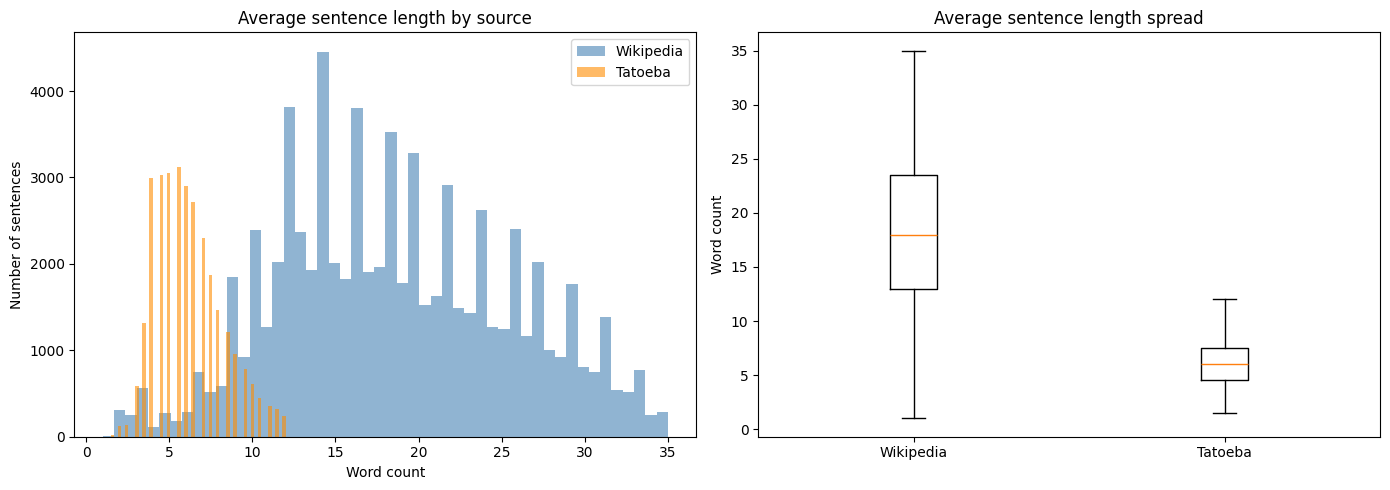

In [7]:
def length_stats(name, pairs_subset):
    ar_lens = np.array([len(tokenize(ar)) for ar, en in pairs_subset])
    en_lens = np.array([len(tokenize(en)) for ar, en in pairs_subset])
    avg_lens = (ar_lens + en_lens) / 2
    print(f"{name:<10} -> avg: {avg_lens.mean():.1f}  (AR mean: {ar_lens.mean():.1f}, EN mean: {en_lens.mean():.1f})")
    return ar_lens, en_lens, avg_lens

wiki_ar_lens, wiki_en_lens, wiki_avg_lens = length_stats("Wikipedia", wiki_pairs)
tat_ar_lens, tat_en_lens, tat_avg_lens = length_stats("Tatoeba", tatoeba_pairs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(wiki_avg_lens, bins=50, color="steelblue", alpha=0.6, label="Wikipedia")
axes[0].hist(tat_avg_lens, bins=50, color="darkorange", alpha=0.6, label="Tatoeba")
axes[0].set_title("Average sentence length by source")
axes[0].set_xlabel("Word count")
axes[0].set_ylabel("Number of sentences")
axes[0].legend()

axes[1].boxplot([wiki_avg_lens, tat_avg_lens], labels=["Wikipedia", "Tatoeba"])
axes[1].set_title("Average sentence length spread")
axes[1].set_ylabel("Word count")

plt.tight_layout()
plt.show()


## Combining the Two Sources

Sample a fixed number of Wikipedia pairs, then add the **full** Tatoeba set on top. Tatoeba stays short (roughly half the average Wikipedia word count or a bit more), so adding all of it doesn't blow up the total token count the way adding an equal number of Wikipedia sentences would.


In [8]:
N_SAMPLE_WIKI = 100_000

if len(wiki_pairs) > N_SAMPLE_WIKI:
    wiki_pairs = random.Random(SEED).sample(wiki_pairs, N_SAMPLE_WIKI)
else:
    print(f"Wikipedia only has {len(wiki_pairs):,} pairs, which is <= {N_SAMPLE_WIKI:,}; keeping all of them.")

pairs = wiki_pairs + tatoeba_pairs
random.Random(SEED).shuffle(pairs)

print(f"Wikipedia sample : {len(wiki_pairs):,}")
print(f"Tatoeba (full)   : {len(tatoeba_pairs):,}")
print(f"Combined pairs   : {len(pairs):,}")


Wikipedia only has 73,712 pairs, which is <= 100,000; keeping all of them.
Wikipedia sample : 73,712
Tatoeba (full)   : 30,569
Combined pairs   : 104,281


In [9]:
print("=== Removing outliers: Combined (Wikipedia + Tatoeba) ===")
pairs = remove_length_outliers(pairs, "Combined")


=== Removing outliers: Combined (Wikipedia + Tatoeba) ===
[Combined] Hard cap (1-35 words/side): removed 0 / 104,281 (0.0%)
[Combined] Avg length IQR bounds [1.0, 35.0]: removed 0 / 104,281 (0.0%)
[Combined] EN/AR ratio bounds [0.59, 1.68] (hard cap 2.5): removed 2,616 / 104,281 (2.5%)
[Combined] TOTAL removed: 2,616 / 104,281 (2.5%)  -> Remaining: 101,665



In [11]:
random.Random(SEED).shuffle(pairs)

n = len(pairs)

n_train = int(0.96 * n)
n_val   = int(0.02 * n)

train_pairs = pairs[:n_train]
val_pairs   = pairs[n_train:n_train + n_val]
test_pairs  = pairs[n_train + n_val:]

print(f"Train: {len(train_pairs):,}")
print(f"Val  : {len(val_pairs):,}")
print(f"Test : {len(test_pairs):,}")

Train: 97,598
Val  : 2,033
Test : 2,034


In [12]:
class Vocab:

    PAD, SOS, EOS, UNK = 0, 1, 2, 3

    SPECIALS = [
        "<pad>",
        "<sos>",
        "<eos>",
        "<unk>"
    ]

    def __init__(self, token_lists, min_freq=2):

        counter = Counter()

        for tokens in token_lists:
            counter.update(tokens)

        self.itos = list(self.SPECIALS)

        for token, count in counter.most_common():

            if count >= min_freq:
                self.itos.append(token)

        self.stoi = {
            token: i
            for i, token in enumerate(self.itos)
        }

    def __len__(self):
        return len(self.itos)

    def encode(
        self,
        tokens,
        add_sos=False,
        add_eos=True
    ):

        ids = [
            self.stoi.get(token, self.UNK)
            for token in tokens
        ]

        if add_sos:
            ids = [self.SOS] + ids

        if add_eos:
            ids = ids + [self.EOS]

        return ids

    def decode(self, ids):

        words = []

        for i in ids:

            if i == self.EOS:
                break

            if i in (self.PAD, self.SOS):
                continue

            if i < len(self.itos):
                words.append(self.itos[i])

        return " ".join(words)

In [14]:
import sentencepiece as spm

# Subword tokenization (BPE) instead of whole-word vocab. This matters a
# lot for Arabic: it's a morphologically rich language (prefixes/suffixes
# stack on a root), so whole-word vocab either explodes in size or turns
# huge numbers of valid words into <unk>. BPE splits rare/unseen words
# into smaller known pieces instead of discarding them, which both keeps
# the vocab small and removes most <unk> tokens at inference time.

SPM_DIR = "/kaggle/working/spm"
os.makedirs(SPM_DIR, exist_ok=True)

SRC_VOCAB_SIZE = 8000  # Arabic (subword) vocab size
TGT_VOCAB_SIZE = 8000  # English (subword) vocab size


def write_corpus(path, sentences):
    with open(path, "w", encoding="utf-8") as f:
        for s in sentences:
            f.write(s + "\n")


ar_train_txt = f"{SPM_DIR}/train_ar.txt"
en_train_txt = f"{SPM_DIR}/train_en.txt"

write_corpus(ar_train_txt, [ar for ar, _ in train_pairs])
write_corpus(en_train_txt, [en for _, en in train_pairs])

# pad/bos/eos/unk ids are pinned to 0/1/2/3 so they line up exactly with
# Vocab.PAD/SOS/EOS/UNK used everywhere else in the notebook (encoder /
# decoder padding_idx, src_mask, greedy & beam decoding loops, etc.) --
# nothing downstream needs to change because of that.
SPM_TRAIN_ARGS = dict(
    model_type="bpe",
    character_coverage=1.0,
    pad_id=0, bos_id=1, eos_id=2, unk_id=3,
    pad_piece="<pad>", bos_piece="<sos>", eos_piece="<eos>", unk_piece="<unk>",
)

spm.SentencePieceTrainer.train(
    input=ar_train_txt,
    model_prefix=f"{SPM_DIR}/spm_ar",
    vocab_size=SRC_VOCAB_SIZE,
    **SPM_TRAIN_ARGS
)

spm.SentencePieceTrainer.train(
    input=en_train_txt,
    model_prefix=f"{SPM_DIR}/spm_en",
    vocab_size=TGT_VOCAB_SIZE,
    **SPM_TRAIN_ARGS
)


class SPVocab:
    """Thin wrapper so a SentencePiece model can be dropped in wherever
    the old word-level Vocab instances (src_vocab / tgt_vocab) were used."""

    PAD, SOS, EOS, UNK = 0, 1, 2, 3

    def __init__(self, model_path):
        self.sp = spm.SentencePieceProcessor(model_file=model_path)

    def __len__(self):
        return self.sp.get_piece_size()

    def encode(self, text, add_sos=False, add_eos=True):
        ids = self.sp.encode(text, out_type=int)

        if add_sos:
            ids = [self.SOS] + ids

        if add_eos:
            ids = ids + [self.EOS]

        return ids

    def encode_pieces(self, text):
        """Subword piece strings (for attention-plot axis labels only)."""
        return self.sp.encode(text, out_type=str)

    def decode(self, ids):
        clean_ids = []

        for i in ids:
            if i == self.EOS:
                break
            if i in (self.PAD, self.SOS):
                continue
            clean_ids.append(int(i))

        return self.sp.decode(clean_ids)


src_vocab = SPVocab(f"{SPM_DIR}/spm_ar.model")
tgt_vocab = SPVocab(f"{SPM_DIR}/spm_en.model")

print("Arabic subword vocab :", len(src_vocab))
print("English subword vocab:", len(tgt_vocab))


Arabic subword vocab : 8000
English subword vocab: 8000


In [15]:
WORK_DIR = "/kaggle/working/nmt_project"
os.makedirs(WORK_DIR, exist_ok=True)


def save_pairs(path, data):

    with open(path, "w", encoding="utf-8") as f:

        for ar, en in data:
            f.write(ar + "\t" + en + "\n")


TRAIN_FILE = f"{WORK_DIR}/train.tsv"
VAL_FILE   = f"{WORK_DIR}/val.tsv"
TEST_FILE  = f"{WORK_DIR}/test.tsv"

save_pairs(TRAIN_FILE, train_pairs)
save_pairs(VAL_FILE, val_pairs)
save_pairs(TEST_FILE, test_pairs)

print("Splits saved.")

Splits saved.


In [16]:
class LazyNMTDataset(Dataset):

    def __init__(self, path, src_vocab, tgt_vocab):

        self.path = path
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab

        self.offsets = []

        with open(path, "rb") as f:

            while True:

                pos = f.tell()
                line = f.readline()

                if not line:
                    break

                self.offsets.append(pos)

    def __len__(self):
        return len(self.offsets)

    def __getitem__(self, idx):

        with open(self.path, "rb") as f:

            f.seek(self.offsets[idx])

            line = f.readline().decode(
                "utf-8"
            ).rstrip("\n")

        ar, en = line.split("\t")

        # NOTE: src_vocab / tgt_vocab are now SentencePiece-backed
        # (SPVocab), so we pass the raw sentence string directly --
        # SentencePiece does its own subword tokenization internally,
        # unlike the old word-level Vocab which needed a pre-tokenized
        # list of words (tokenize(text)).
        src_ids = self.src_vocab.encode(
            ar,
            add_sos=False,
            add_eos=True
        )

        tgt_ids = self.tgt_vocab.encode(
            en,
            add_sos=True,
            add_eos=True
        )

        return (
            torch.tensor(src_ids, dtype=torch.long),
            torch.tensor(tgt_ids, dtype=torch.long)
        )


In [17]:
def collate_fn(batch):

    src, tgt = zip(*batch)

    src_lens = torch.tensor(
        [len(x) for x in src],
        dtype=torch.long
    )

    src = pad_sequence(
        src,
        batch_first=True,
        padding_value=Vocab.PAD
    )

    tgt = pad_sequence(
        tgt,
        batch_first=True,
        padding_value=Vocab.PAD
    )

    return src, src_lens, tgt

In [18]:
class RNNEncoder(nn.Module):

    def __init__(
        self,
        vocab_size,
        embed_dim,
        enc_hidden,
        dec_hidden,
        dropout
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=Vocab.PAD
        )

        self.rnn = nn.LSTM(
            embed_dim,
            enc_hidden,
            batch_first=True,
            bidirectional=True
        )

        self.fc_h = nn.Linear(
            2 * enc_hidden,
            dec_hidden
        )

        self.fc_c = nn.Linear(
            2 * enc_hidden,
            dec_hidden
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_lens):

        emb = self.dropout(
            self.embedding(src)
        )

        packed = pack_padded_sequence(
            emb,
            src_lens.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        outputs, (h, c) = self.rnn(packed)

        outputs, _ = pad_packed_sequence(
            outputs,
            batch_first=True
        )

        h_cat = torch.cat(
            [h[0], h[1]],
            dim=1
        )

        c_cat = torch.cat(
            [c[0], c[1]],
            dim=1
        )

        h0 = torch.tanh(
            self.fc_h(h_cat)
        ).unsqueeze(0)

        c0 = torch.tanh(
            self.fc_c(c_cat)
        ).unsqueeze(0)

        return outputs, (h0, c0)

In [19]:
class BahdanauAttention(nn.Module):

    def __init__(
        self,
        enc_hidden,
        dec_hidden,
        attn_dim
    ):
        super().__init__()

        self.W_enc = nn.Linear(
            2 * enc_hidden,
            attn_dim,
            bias=False
        )

        self.W_dec = nn.Linear(
            dec_hidden,
            attn_dim,
            bias=False
        )

        self.v = nn.Linear(
            attn_dim,
            1,
            bias=False
        )

    def forward(
        self,
        dec_h,
        enc_outputs,
        src_mask
    ):

        enc_proj = self.W_enc(
            enc_outputs
        )

        dec_proj = self.W_dec(
            dec_h
        ).unsqueeze(1)

        scores = self.v(
            torch.tanh(
                enc_proj + dec_proj
            )
        ).squeeze(-1)

        scores = scores.masked_fill(
            ~src_mask,
            float("-inf")
        )

        weights = torch.softmax(
            scores,
            dim=-1
        )

        context = torch.bmm(
            weights.unsqueeze(1),
            enc_outputs
        ).squeeze(1)

        return context, weights

In [20]:
class RNNDecoder(nn.Module):

    def __init__(
        self,
        vocab_size,
        embed_dim,
        enc_hidden,
        dec_hidden,
        attn_dim,
        dropout
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=Vocab.PAD
        )

        self.attn = BahdanauAttention(
            enc_hidden,
            dec_hidden,
            attn_dim
        )

        self.rnn = nn.LSTM(
            embed_dim + 2 * enc_hidden,
            dec_hidden,
            batch_first=True
        )

        self.fc_out = nn.Linear(
            dec_hidden +
            2 * enc_hidden +
            embed_dim,
            vocab_size
        )

        self.dropout = nn.Dropout(dropout)

    def forward(
        self,
        tgt_step,
        hidden,
        enc_outputs,
        src_mask
    ):

        emb = self.dropout(
            self.embedding(tgt_step)
        ).unsqueeze(1)

        context, attn_w = self.attn(
            hidden[0].squeeze(0),
            enc_outputs,
            src_mask
        )

        rnn_input = torch.cat(
            [
                emb,
                context.unsqueeze(1)
            ],
            dim=-1
        )

        out, hidden = self.rnn(
            rnn_input,
            hidden
        )

        out = out.squeeze(1)

        logits = self.fc_out(
            torch.cat(
                [
                    out,
                    context,
                    emb.squeeze(1)
                ],
                dim=-1
            )
        )

        return logits, hidden, attn_w

In [21]:
class Seq2SeqRNN(nn.Module):

    def __init__(
        self,
        encoder,
        decoder
    ):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder

    def forward(
        self,
        src,
        src_lens,
        tgt,
        teacher_forcing_ratio=1.0
    ):

        B, T = tgt.shape

        vocab_size = (
            self.decoder.fc_out.out_features
        )

        src_mask = (
            src != Vocab.PAD
        )

        enc_outputs, hidden = self.encoder(
            src,
            src_lens
        )

        outputs = torch.zeros(
            B,
            T,
            vocab_size,
            device=src.device
        )

        input_step = tgt[:, 0]

        for t in range(1, T):

            logits, hidden, _ = self.decoder(
                input_step,
                hidden,
                enc_outputs,
                src_mask
            )

            outputs[:, t] = logits

            use_tf = (
                random.random()
                < teacher_forcing_ratio
            )

            input_step = (
                tgt[:, t]
                if use_tf
                else logits.argmax(-1)
            )

        return outputs

    @torch.no_grad()
    def greedy_decode(
        self,
        src,
        src_lens,
        max_len=30
    ):

        self.eval()

        src_mask = (
            src != Vocab.PAD
        )

        enc_outputs, hidden = self.encoder(
            src,
            src_lens
        )

        input_step = torch.full(
            (src.size(0),),
            Vocab.SOS,
            dtype=torch.long,
            device=src.device
        )

        tokens = []

        for _ in range(max_len):

            logits, hidden, _ = self.decoder(
                input_step,
                hidden,
                enc_outputs,
                src_mask
            )

            preds = logits.argmax(-1)

            tokens.append(preds)

            input_step = preds

        return torch.stack(
            tokens,
            dim=1
        )

In [22]:
EMBED_DIM = 128
ENC_HIDDEN = 192
DEC_HIDDEN = 256
ATTN_DIM = 192
DROPOUT = 0.4

encoder = RNNEncoder(
    len(src_vocab),
    EMBED_DIM,
    ENC_HIDDEN,
    DEC_HIDDEN,
    DROPOUT
)

decoder = RNNDecoder(
    len(tgt_vocab),
    EMBED_DIM,
    ENC_HIDDEN,
    DEC_HIDDEN,
    ATTN_DIM,
    DROPOUT
)

model = Seq2SeqRNN(
    encoder,
    decoder
).to(device)

params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Trainable parameters: {params:,}")

Trainable parameters: 9,803,264


In [23]:
EPOCHS = 40
LR = 7e-4
WEIGHT_DECAY = 1e-5
CLIP = 1.0
PATIENCE = 3

criterion = nn.CrossEntropyLoss(
    ignore_index=Vocab.PAD,
    label_smoothing=0.1
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=1
)

In [24]:
def train_epoch(model, loader, teacher_forcing_ratio=1.0):

    model.train()

    total_loss = 0

    for src, src_lens, tgt in tqdm(
        loader,
        desc="Train",
        leave=False
    ):

        src = src.to(
            device,
            non_blocking=True
        )

        tgt = tgt.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        output = model(
            src,
            src_lens,
            tgt,
            teacher_forcing_ratio=teacher_forcing_ratio
        )

        output = output[:, 1:].reshape(
            -1,
            output.size(-1)
        )

        target = tgt[:, 1:].reshape(-1)

        loss = criterion(
            output,
            target
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            CLIP
        )

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def evaluate_loss(model, loader):


    model.eval()

    total_loss = 0

    for src, src_lens, tgt in tqdm(
        loader,
        desc="Val",
        leave=False
    ):

        src = src.to(
            device,
            non_blocking=True
        )

        tgt = tgt.to(
            device,
            non_blocking=True
        )

        output = model(
            src,
            src_lens,
            tgt,
            teacher_forcing_ratio=1.0
        )

        output = output[:, 1:].reshape(
            -1,
            output.size(-1)
        )

        target = tgt[:, 1:].reshape(-1)

        loss = criterion(
            output,
            target
        )

        total_loss += loss.item()

    return total_loss / len(loader)


In [25]:
BATCH_SIZE = 64

train_ds = LazyNMTDataset(
    TRAIN_FILE,
    src_vocab,
    tgt_vocab
)

val_ds = LazyNMTDataset(
    VAL_FILE,
    src_vocab,
    tgt_vocab
)

test_ds = LazyNMTDataset(
    TEST_FILE,
    src_vocab,
    tgt_vocab
)


train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=True
)

print("Train:", len(train_ds))
print("Val  :", len(val_ds))
print("Test :", len(test_ds))
print("Train batches:", len(train_loader))

Train: 97598
Val  : 2033
Test : 2034
Train batches: 1525


In [26]:
history = {
    "train": [],
    "val": []
}

best_val = float("inf")
bad_epochs = 0


MIN_TEACHER_FORCING = 0.5

for epoch in range(1, EPOCHS + 1):

    start = time.time()

    tf_ratio = max(
        MIN_TEACHER_FORCING,
        1.0 - (epoch - 1) * (1.0 - MIN_TEACHER_FORCING) / max(1, EPOCHS - 1)
    )

    train_loss = train_epoch(
        model,
        train_loader,
        teacher_forcing_ratio=tf_ratio
    )

    val_loss = evaluate_loss(
        model,
        val_loader
    )

    scheduler.step(val_loss)

    history["train"].append(train_loss)
    history["val"].append(val_loss)

    lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch:02d} | "
        f"Train: {train_loss:.4f} | "
        f"Val: {val_loss:.4f} | "
        f"TF: {tf_ratio:.2f} | "
        f"LR: {lr:.1e} | "
        f"Time: {time.time()-start:.1f}s"
    )

    if val_loss < best_val:

        best_val = val_loss
        bad_epochs = 0

        torch.save(
            model.state_dict(),
            f"{WORK_DIR}/best_model.pt"
        )

    else:

        bad_epochs += 1

        if bad_epochs >= PATIENCE:

            print("Early stopping.")
            break


model.load_state_dict(
    torch.load(
        f"{WORK_DIR}/best_model.pt",
        map_location=device
    )
)

print(f"Best validation loss: {best_val:.4f}")


Train:   0%|          | 0/1525 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 01 | Train: 5.9523 | Val: 5.3470 | TF: 1.00 | LR: 7.0e-04 | Time: 271.2s


Train:   0%|          | 0/1525 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

...

Val:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 33 | Train: 3.7023 | Val: 3.5918 | TF: 0.59 | LR: 8.7e-05 | Time: 272.6s


Train:   0%|          | 0/1525 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 34 | Train: 3.6889 | Val: 3.5937 | TF: 0.58 | LR: 8.7e-05 | Time: 268.5s
Early stopping.
Best validation loss: 3.5820


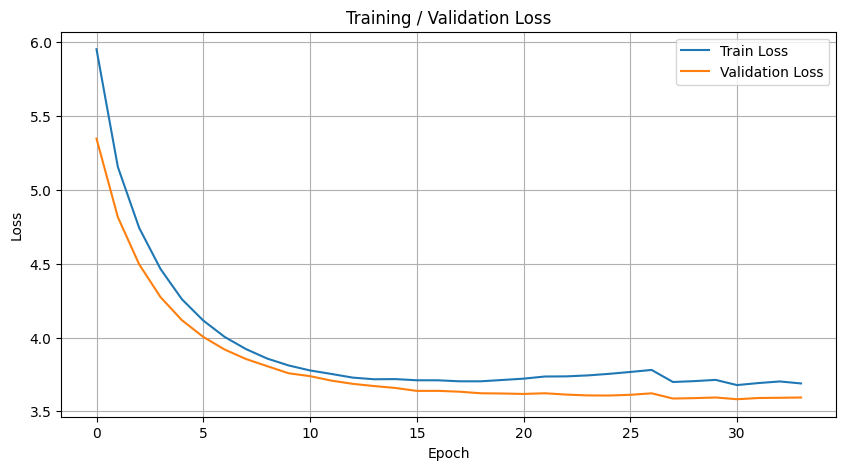

In [27]:
plt.figure(figsize=(10, 5))

plt.plot(
    history["train"],
    label="Train Loss"
)

plt.plot(
    history["val"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training / Validation Loss")

plt.legend()
plt.grid()

plt.show()

In [28]:
@torch.no_grad()
def translate(
    model,
    arabic_sentence,
    max_len=30
):

    model.eval()

    normalized = normalize_arabic(arabic_sentence)

    # src_vocab is now SentencePiece-backed: encode the raw normalized
    # string directly (it does its own subword tokenization). We keep
    # the subword pieces separately just for the attention-plot labels.
    src_ids = src_vocab.encode(
        normalized,
        add_sos=False,
        add_eos=True
    )

    tokens = [
        piece.replace("\u2581", " ").strip()
        for piece in src_vocab.encode_pieces(normalized)
    ]

    src = torch.tensor(
        [src_ids],
        dtype=torch.long,
        device=device
    )

    src_lens = torch.tensor(
        [len(src_ids)],
        dtype=torch.long
    )

    src_mask = (
        src != Vocab.PAD
    )

    enc_outputs, hidden = model.encoder(
        src,
        src_lens
    )

    input_step = torch.tensor(
        [Vocab.SOS],
        dtype=torch.long,
        device=device
    )

    generated = []
    attention_weights = []

    for _ in range(max_len):

        logits, hidden, attn = model.decoder(
            input_step,
            hidden,
            enc_outputs,
            src_mask
        )

        pred = logits.argmax(-1).item()

        if pred == Vocab.EOS:
            break

        generated.append(pred)

        attention_weights.append(
            attn[0].cpu().numpy()
        )

        input_step = torch.tensor(
            [pred],
            dtype=torch.long,
            device=device
        )

    translation = tgt_vocab.decode(
        generated
    )

    return (
        translation,
        np.array(attention_weights),
        tokens
    )


In [29]:
def show_attention(
    arabic_sentence
):

    translation, attention, src_tokens = translate(
        model,
        arabic_sentence
    )

    tgt_tokens = translation.split()

    plt.figure(
        figsize=(12, 7)
    )

    plt.imshow(
        attention,
        aspect="auto"
    )

    fixed_tokens = [fix_arabic_display(tok) for tok in src_tokens]
    plt.xticks(range(len(fixed_tokens)), fixed_tokens, rotation=45, ha="right")

    plt.yticks(
        range(len(tgt_tokens)),
        tgt_tokens
    )

    plt.xlabel(
        "Arabic Source Words"
    )

    plt.ylabel(
        "English Generated Words"
    )

    plt.title(
        "Bahdanau Attention Weights"
    )

    plt.colorbar(
        label="Attention Weight"
    )

    plt.tight_layout()
    plt.show()

    print("Arabic :", arabic_sentence)
    print("English:", translation)

In [30]:
@torch.no_grad()
def predict_dataset(
    model,
    dataset_path
):

    references = []
    hypotheses = []

    with open(
        dataset_path,
        "r",
        encoding="utf-8"
    ) as f:

        for line in tqdm(
            f,
            desc="Translating Test Set"
        ):

            ar, en = line.rstrip(
                "\n"
            ).split("\t")

            prediction, _, _ = translate(
                model,
                ar
            )

            references.append(en)
            hypotheses.append(
                prediction
            )

    return references, hypotheses

In [31]:
def detokenize_en(text):
    """Undo the space-padding around punctuation added by normalize_english,
    so sacrebleu scores natural (not pre-tokenized) text as intended."""
    text = re.sub(r"\s+([.,!?'])", r"\1", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


references, hypotheses = predict_dataset(
    model,
    TEST_FILE
)

references_detok = [detokenize_en(r) for r in references]
hypotheses_detok = [detokenize_en(h) for h in hypotheses]

bleu = sacrebleu.corpus_bleu(
    hypotheses_detok,
    [references_detok]
)

print(f"Test BLEU: {bleu.score:.2f}")


Translating Test Set: 0it [00:00, ?it/s]

Test BLEU: 24.35


In [32]:
@torch.no_grad()
def compute_bleu_on_loader(model, dataset_path):

    references = []
    hypotheses = []

    with open(dataset_path, "r", encoding="utf-8") as f:

        for line in tqdm(f, desc="Translating Validation Set"):

            ar, en = line.rstrip("\n").split("\t")

            prediction, _, _ = translate(model, ar)

            references.append(detokenize_en(en))
            hypotheses.append(detokenize_en(prediction))

    bleu = sacrebleu.corpus_bleu(
        hypotheses,
        [references]
    )

    return bleu


val_bleu = compute_bleu_on_loader(
    model,
    VAL_FILE
)

print(f"Validation BLEU: {val_bleu.score:.2f}")


Translating Validation Set: 0it [00:00, ?it/s]

Validation BLEU: 23.97


## Error Analysis

In [33]:
@torch.no_grad()
def compute_sentence_bleu_table(model, dataset_path):

    rows = []

    with open(dataset_path, "r", encoding="utf-8") as f:

        for line in tqdm(f, desc="Scoring sentences"):

            ar, en = line.rstrip("\n").split("\t")

            prediction, _, _ = translate(model, ar)

            ref = detokenize_en(en)
            hyp = detokenize_en(prediction)

            score = sacrebleu.sentence_bleu(hyp, [ref]).score

            rows.append({
                "arabic": ar,
                "reference": ref,
                "prediction": hyp,
                "bleu": score,
                "ref_len": len(ref.split()),
                "pred_len": len(hyp.split())
            })

    return pd.DataFrame(rows)


error_df = compute_sentence_bleu_table(model, TEST_FILE)

worst = error_df.sort_values("bleu").head(15)

print("=== 15 Worst Translations (lowest sentence BLEU) ===\n")
for _, row in worst.iterrows():
    print(f"AR : {row['arabic']}")
    print(f"REF: {row['reference']}")
    print(f"HYP: {row['prediction']}")
    print(f"BLEU: {row['bleu']:.2f} | ref_len={row['ref_len']} pred_len={row['pred_len']}")
    print()


Scoring sentences: 0it [00:00, ?it/s]

=== 15 Worst Translations (lowest sentence BLEU) ===

AR : لم يعد هذا الفسان يناسب مقاسي .
REF: my dress does n't fit anymore!
HYP: this is no longer to myself.
BLEU: 0.00 | ref_len=6 pred_len=6

AR : ادخلت شركه طيران طائرات بوينج 737 وبوينج 757 الي الاسطول في الثمانينات ، تبعه ادخال طائرات بوينج 747-400 وبوينج 767 وبوينج 777 في التسعينات .
REF: the airline introduced the boeing 737 and boeing 757 into the fleet in the 1980s, followed by the boeing 747400, boeing 767 and boeing 777 in the 1990s.
HYP: the aircraft air boeing 73777777777, the aircraft of the774007777777
BLEU: 0.73 | ref_len=28 pred_len=9

AR : عندما اوضح بودلي بان لا خيار اخر امامه خاصه وان الحرب قد انتهت ثم تسائل وماذا عليه ان يفعل اذن ، حينها اقترح عليه لورنس : " اذهب وخالط العرب " .
REF: when he replied that he had no other prospects now that the war was over and asking what he should do, lawrence suggested go live with the arabs.
HYP: when theley, he does not choice choice of special or, and then it may then and then

In [34]:
def has_repetition(text, n=2):
    tokens = text.split()
    for i in range(len(tokens) - n):
        if tokens[i:i + n] == tokens[i + n:i + 2 * n]:
            return True
    return False


short_preds = (worst["pred_len"] < worst["ref_len"] * 0.5).sum()
repeated = worst["prediction"].apply(has_repetition).sum()

print("Out of the 15 worst test examples:")
print(f" - {short_preds} have predictions under half the reference length (possible truncation / early <eos>)")
print(f" - {repeated} contain a repeated word sequence (possible decoding loop)")
print()
print(f"Overall test BLEU        : {bleu.score:.2f}")
print(f"Mean sentence BLEU (all) : {error_df['bleu'].mean():.2f}")
print(f"Mean sentence BLEU (worst 15): {worst['bleu'].mean():.2f}")


Out of the 15 worst test examples:
 - 1 have predictions under half the reference length (possible truncation / early <eos>)
 - 2 contain a repeated word sequence (possible decoding loop)

Overall test BLEU        : 24.35
Mean sentence BLEU (all) : 27.82
Mean sentence BLEU (worst 15): 2.27


In [35]:
@torch.no_grad()
def beam_search_translate(
    model,
    arabic_sentence,
    beam_width=5,
    max_len=30,
    length_penalty=0.7
):
    model.eval()

    # src_vocab is SentencePiece-backed: encode the raw normalized string
    # directly instead of a pre-tokenized word list.
    normalized = normalize_arabic(arabic_sentence)
    src_ids = src_vocab.encode(normalized, add_sos=False, add_eos=True)

    src = torch.tensor([src_ids], dtype=torch.long, device=device)
    src_lens = torch.tensor([len(src_ids)], dtype=torch.long)
    src_mask = (src != Vocab.PAD)

    enc_outputs, hidden = model.encoder(src, src_lens)

    # each beam: (token_id_sequence, cumulative_log_prob, hidden_state)
    beams = [([Vocab.SOS], 0.0, hidden)]
    completed = []

    for _ in range(max_len):
        candidates = []

        for seq, score, hid in beams:
            if seq[-1] == Vocab.EOS:
                completed.append((seq, score))
                continue

            input_step = torch.tensor([seq[-1]], dtype=torch.long, device=device)
            logits, hid_new, _ = model.decoder(input_step, hid, enc_outputs, src_mask)
            log_probs = torch.log_softmax(logits, dim=-1).squeeze(0)

            topk_log_probs, topk_ids = log_probs.topk(beam_width)

            for lp, idx in zip(topk_log_probs.tolist(), topk_ids.tolist()):
                candidates.append((seq + [idx], score + lp, hid_new))

        if not candidates:
            break

        candidates.sort(key=lambda b: b[1] / (len(b[0]) ** length_penalty), reverse=True)
        beams = candidates[:beam_width]

        if all(seq[-1] == Vocab.EOS for seq, _, _ in beams):
            completed.extend([(seq, score) for seq, score, _ in beams])
            break

    if not completed:
        completed = [(seq, score) for seq, score, _ in beams]

    best_seq, _ = max(completed, key=lambda x: x[1] / (len(x[0]) ** length_penalty))
    generated = [t for t in best_seq if t not in (Vocab.SOS, Vocab.EOS)]

    return tgt_vocab.decode(generated)


In [36]:
@torch.no_grad()
def evaluate_beam_search_bleu(model, dataset_path, beam_width=5):
    references = []
    hypotheses = []

    with open(dataset_path, "r", encoding="utf-8") as f:
        for line in tqdm(f, desc="Beam Search Translating"):
            ar, en = line.rstrip("\n").split("\t")
            prediction = beam_search_translate(model, ar, beam_width=beam_width)

            references.append(detokenize_en(en))
            hypotheses.append(detokenize_en(prediction))

    return sacrebleu.corpus_bleu(hypotheses, [references])


beam_bleu = evaluate_beam_search_bleu(model, TEST_FILE, beam_width=5)

print(f"Test BLEU (beam search, width=5): {beam_bleu.score:.2f}")
print(f"Test BLEU (greedy, from earlier): {bleu.score:.2f}")

Beam Search Translating: 0it [00:00, ?it/s]

Test BLEU (beam search, width=5): 27.48
Test BLEU (greedy, from earlier): 24.35


In [37]:
!pip -q install arabic_reshaper python-bidi

import arabic_reshaper
from bidi.algorithm import get_display

def fix_arabic_display(text):
    reshaped = arabic_reshaper.reshape(text)
    return get_display(reshaped)

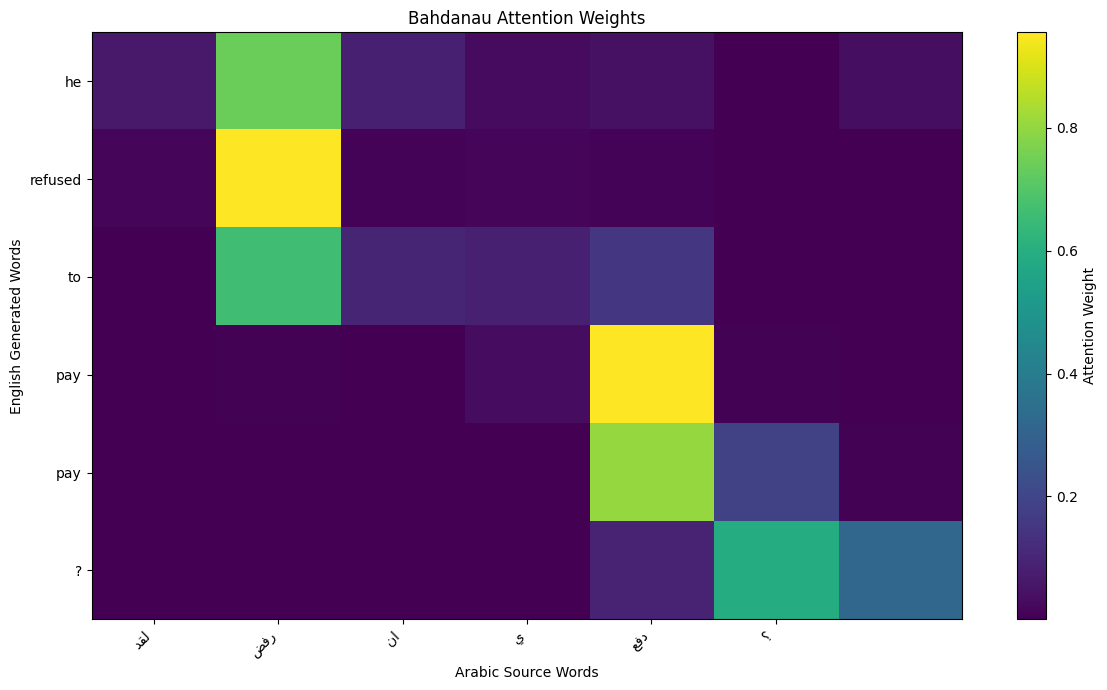

Arabic : لقد رفض ان يدفع ؟
English: he refused to pay pay ?


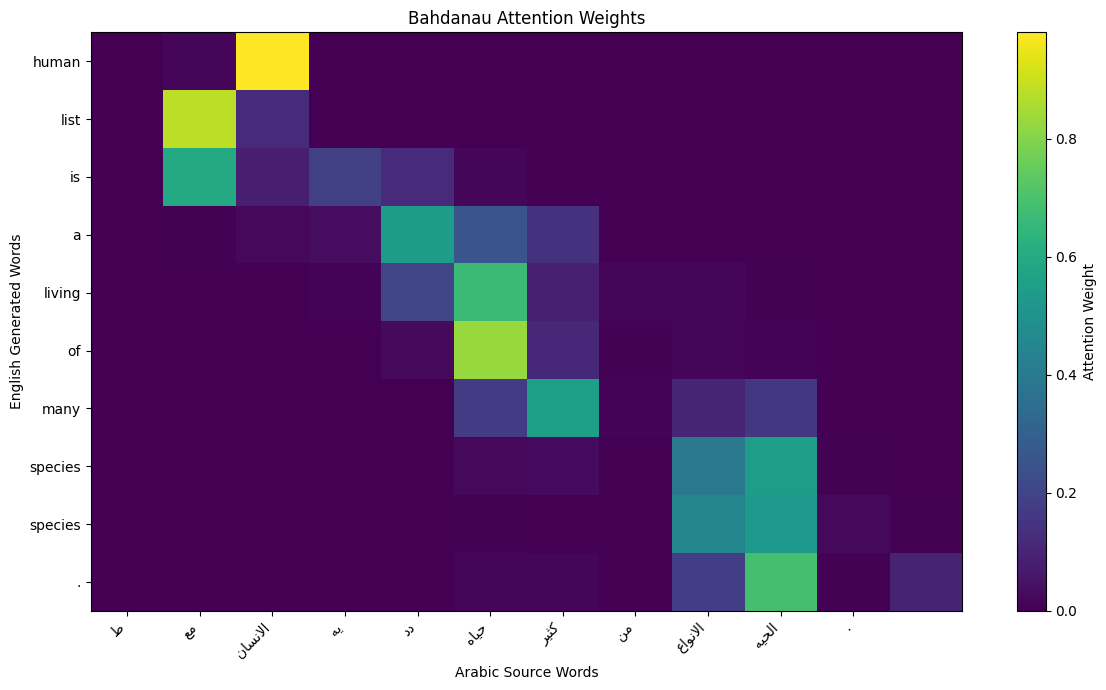

Arabic : طمع الانسان يهدد حياه كثير من الانواع الحيه .
English: human list is a living of many species species .


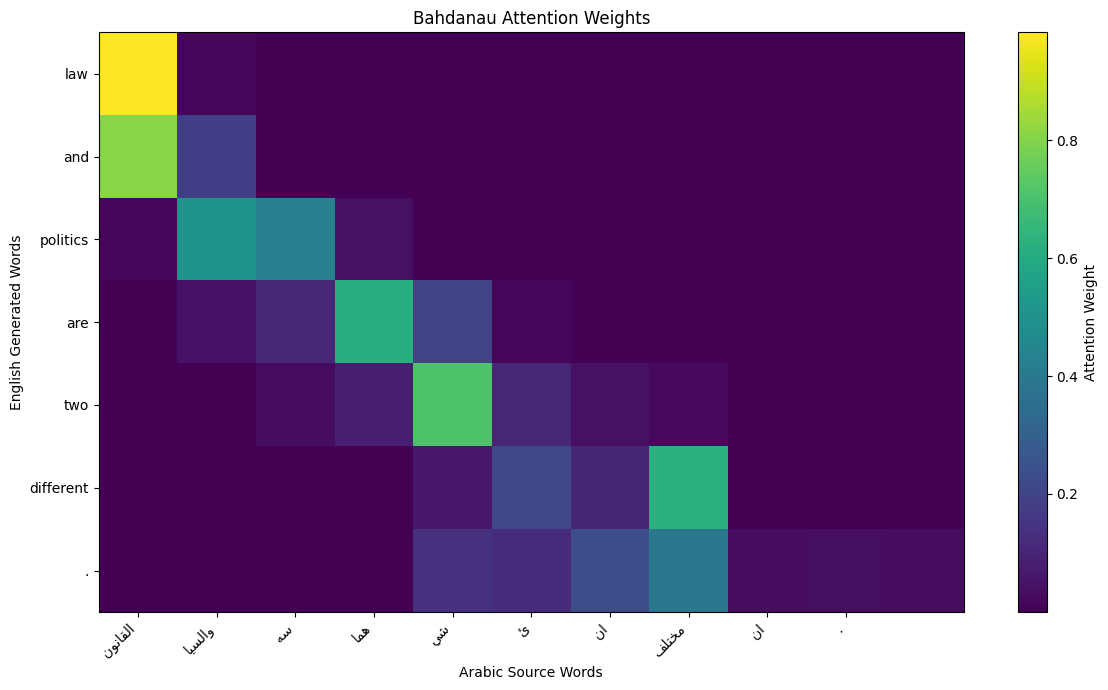

Arabic : القانون والسياسه هما شيئان مختلفان .
English: law and politics are two different .


In [38]:
# Attention weight visualization for a few sample sentences
sample_sentences = [
    "لقد رفض ان يدفع ؟",
    "طمع الانسان يهدد حياه كثير من الانواع الحيه .",
    "القانون والسياسه هما شيئان مختلفان .",
]

for sent in sample_sentences:
    show_attention(sent)

In [39]:
best = error_df.sort_values("bleu", ascending=False).head(10)

print("=== Top 10 Best Translations (highest sentence BLEU) ===\n")
for _, row in best.iterrows():
    print(f"AR : {row['arabic']}")
    print(f"REF: {row['reference']}")
    print(f"HYP: {row['prediction']}")
    print(f"BLEU: {row['bleu']:.2f} | ref_len={row['ref_len']} pred_len={row['pred_len']}")
    print()

=== Top 10 Best Translations (highest sentence BLEU) ===

AR : تبلغ مساحه اغيو 45 . 55 كم2 .
REF: the total area is 45. 55 km.
HYP: the total area is 45. 55 km.
BLEU: 100.00 | ref_len=7 pred_len=7

AR : لم يكذب .
REF: he didn't lie.
HYP: he didn't lie.
BLEU: 100.00 | ref_len=3 pred_len=3

AR : تناولت ليلي اقراص النوم .
REF: layla took sleeping pills.
HYP: layla took sleeping pills.
BLEU: 100.00 | ref_len=4 pred_len=4

AR : تلقي سامي حكما بالسجن المؤبد .
REF: sami received a life sentence.
HYP: sami received a life sentence.
BLEU: 100.00 | ref_len=5 pred_len=5

AR : اشتريت سياره جديده .
REF: i bought a new car.
HYP: i bought a new car.
BLEU: 100.00 | ref_len=5 pred_len=5

AR : كن مستعدا
REF: be prepared.
HYP: be prepared.
BLEU: 100.00 | ref_len=2 pred_len=2

AR : افعل كما اقول
REF: do as i say.
HYP: do as i say.
BLEU: 100.00 | ref_len=4 pred_len=4

AR : شكرا .
REF: thanks.
HYP: thanks.
BLEU: 100.00 | ref_len=1 pred_len=1

AR : انني استمع الي المذياع .
REF: i'm listening to the radio.
HY

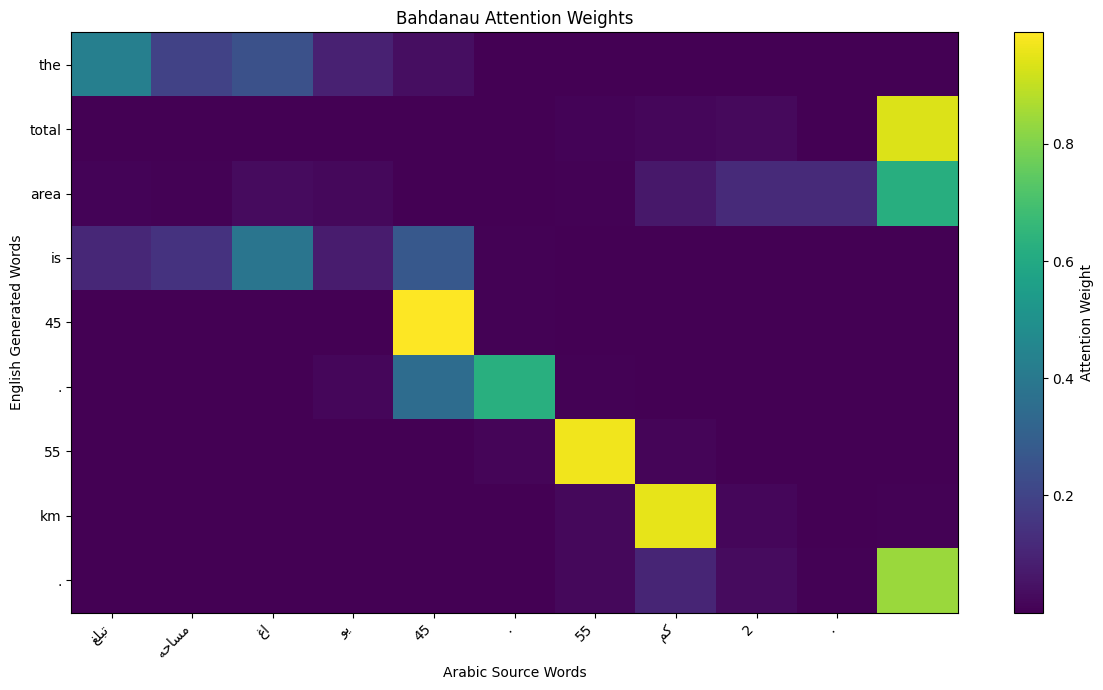

Arabic : تبلغ مساحه اغيو 45 . 55 كم2 .
English: the total area is 45 . 55 km .


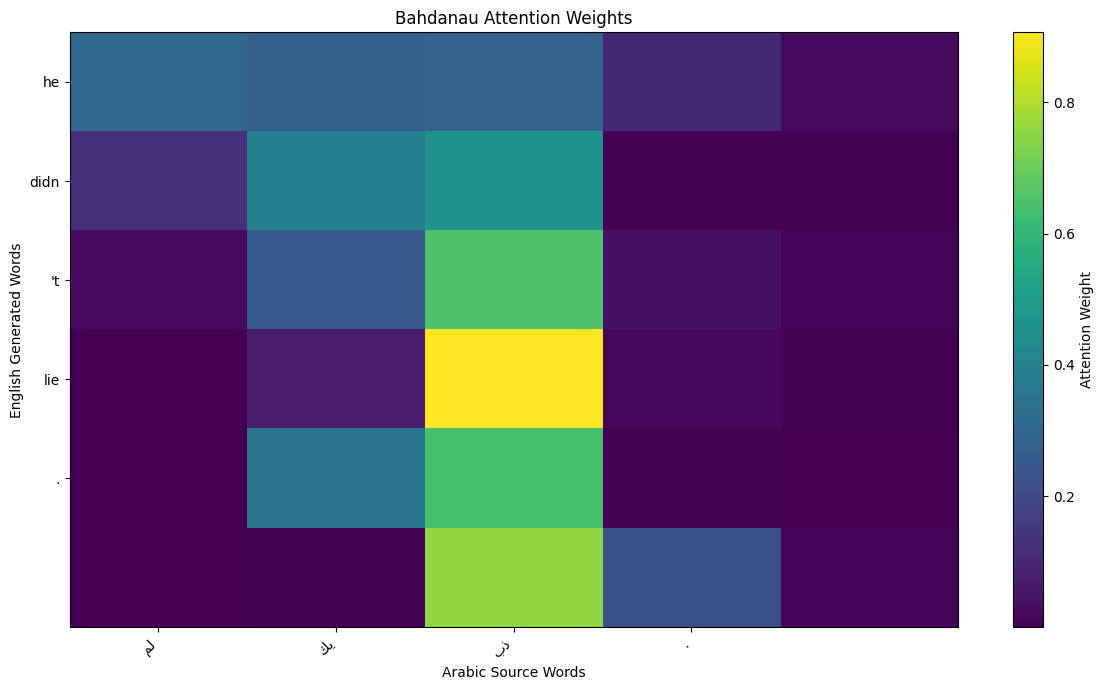

Arabic : لم يكذب .
English: he didn 't lie .


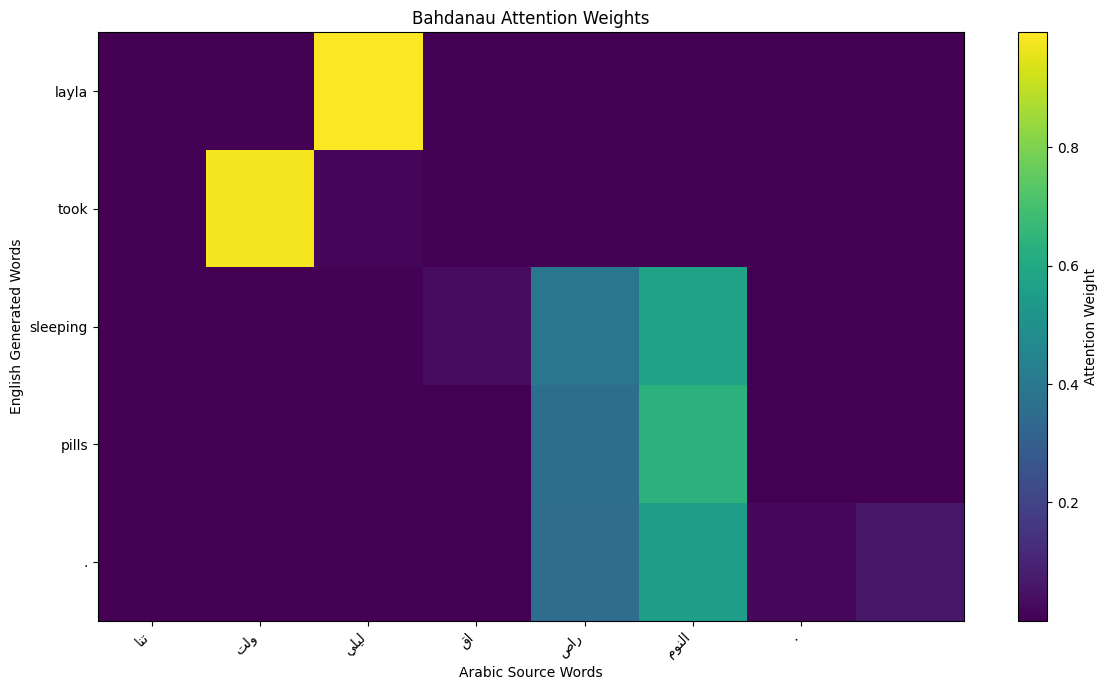

Arabic : تناولت ليلي اقراص النوم .
English: layla took sleeping pills .


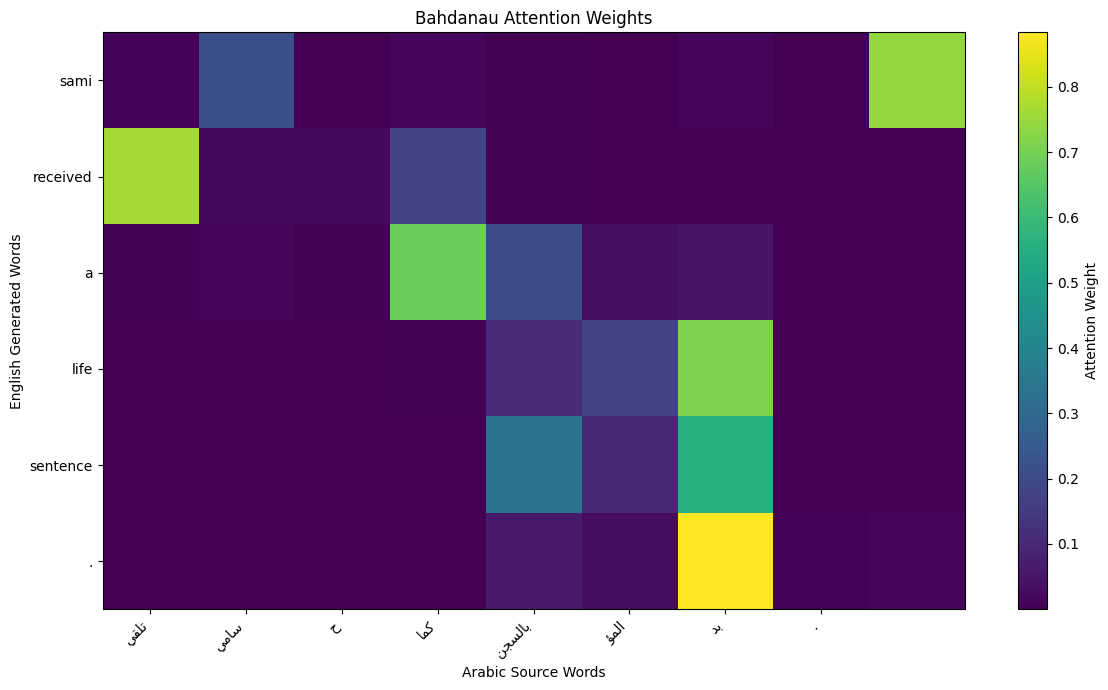

Arabic : تلقي سامي حكما بالسجن المؤبد .
English: sami received a life sentence .


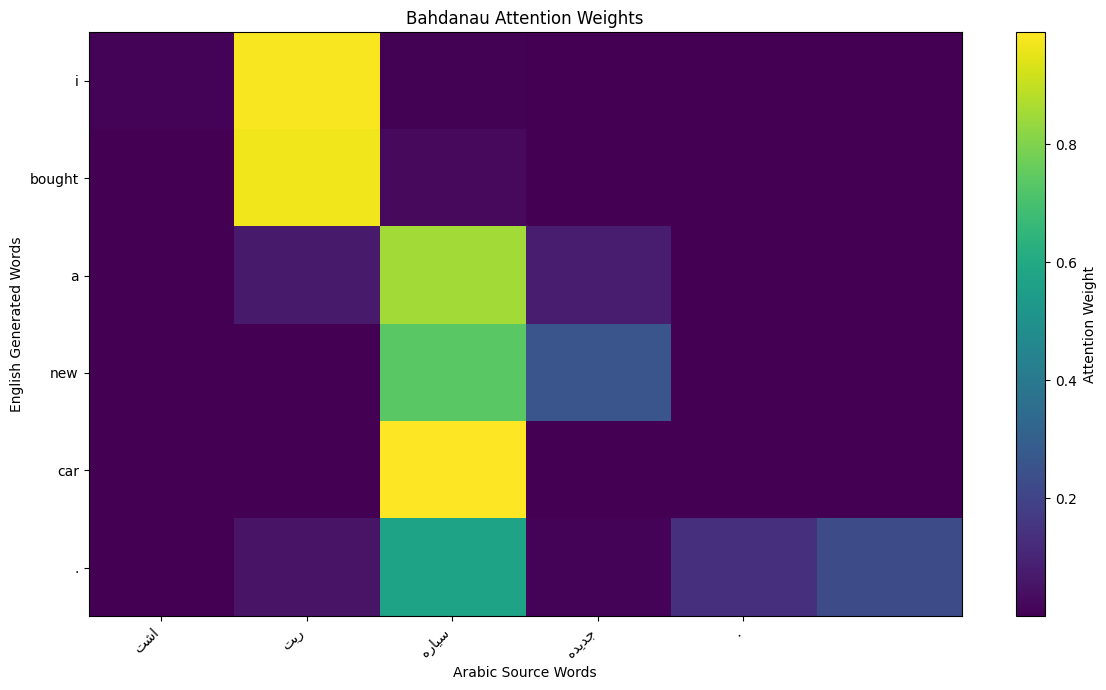

Arabic : اشتريت سياره جديده .
English: i bought a new car .


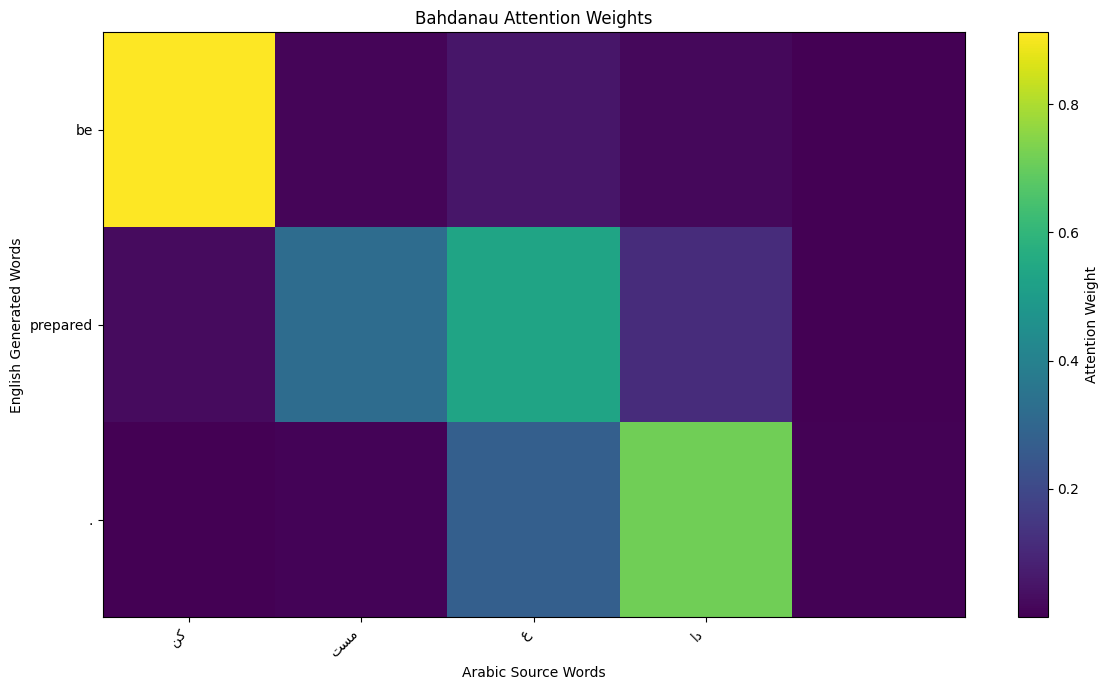

Arabic : كن مستعدا
English: be prepared .


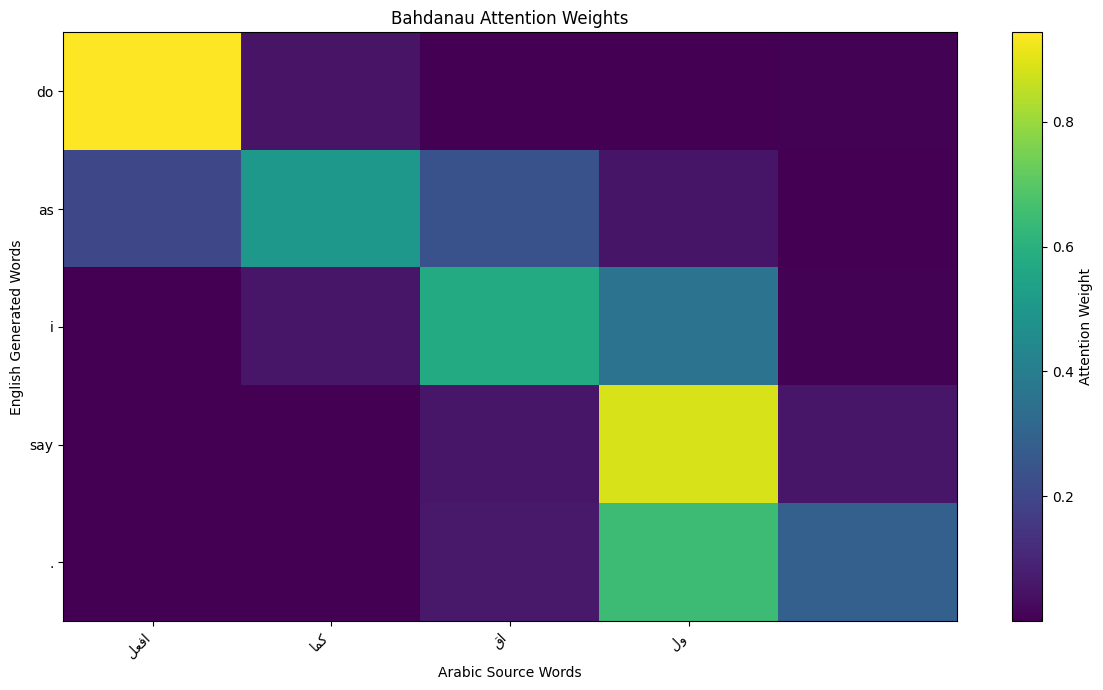

Arabic : افعل كما اقول
English: do as i say .


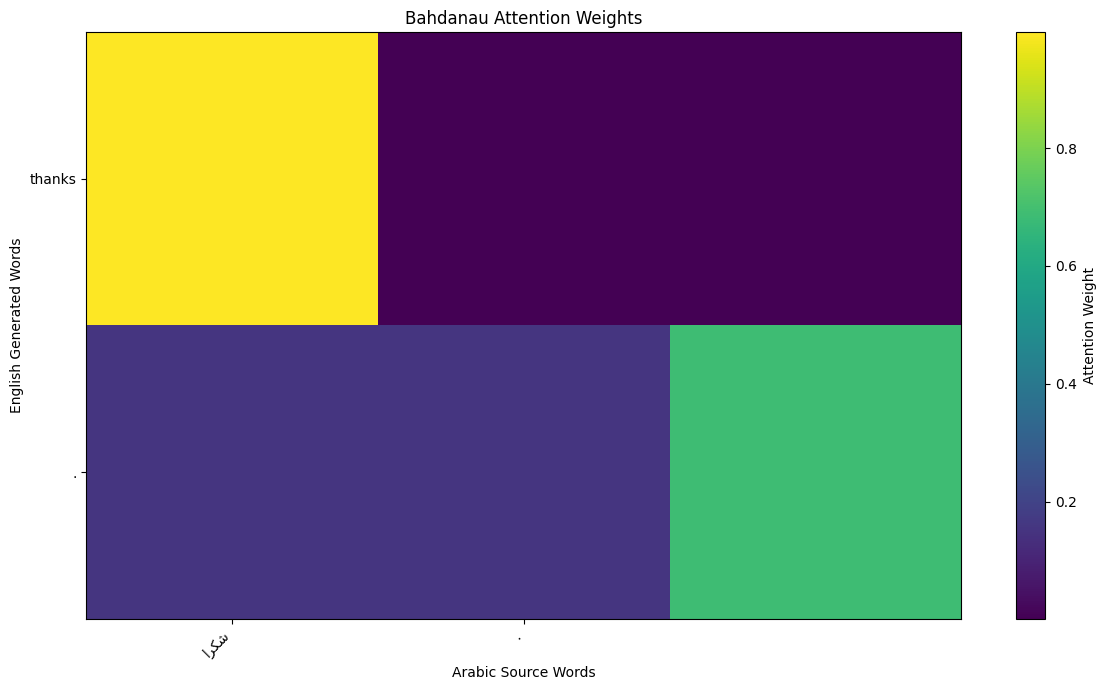

Arabic : شكرا .
English: thanks .


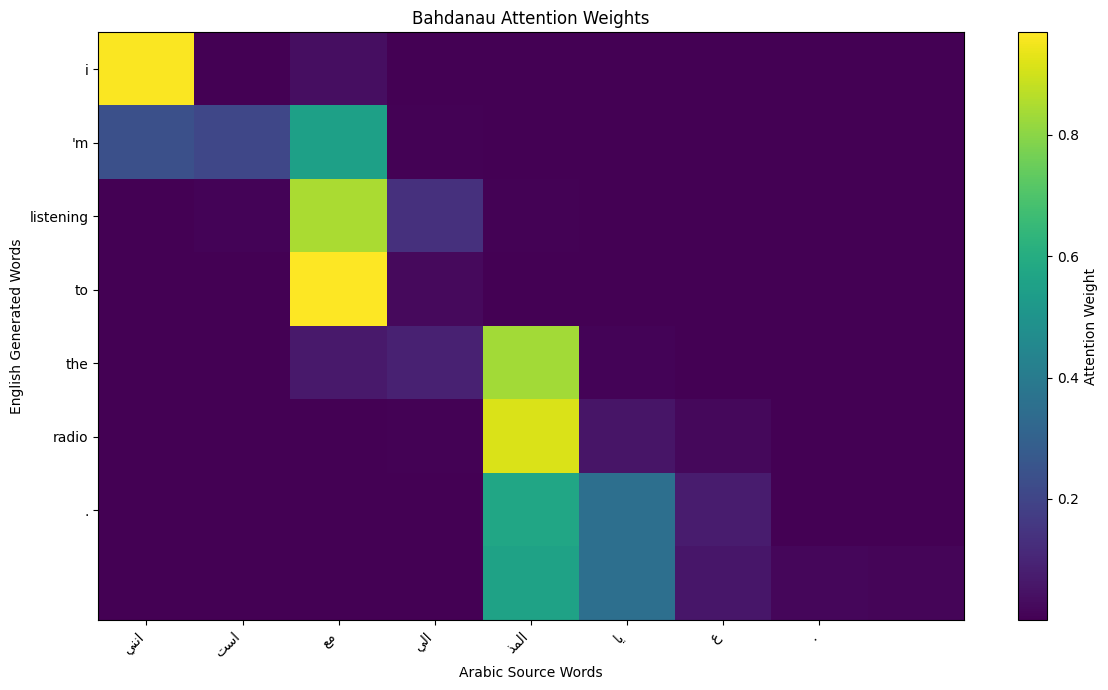

Arabic : انني استمع الي المذياع .
English: i 'm listening to the radio .


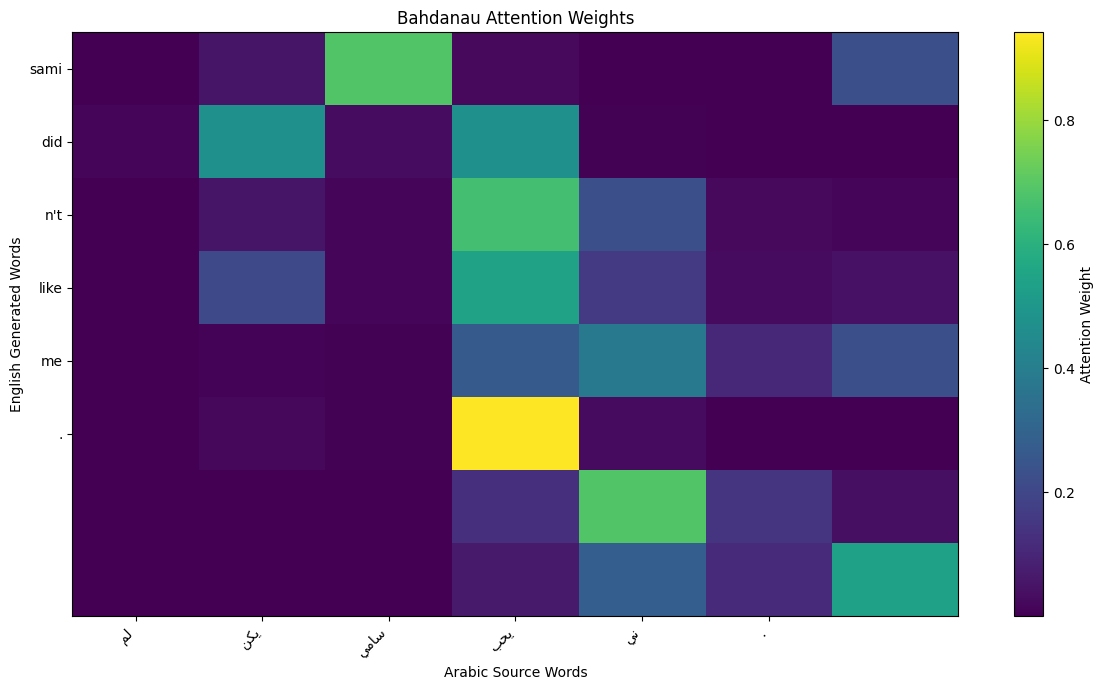

Arabic : لم يكن سامي يحبني .
English: sami did n't like me .


In [40]:
for sent in best["arabic"]:
    show_attention(sent)

In [41]:
import shutil

SAVE_DIR = f"{WORK_DIR}/ar2en_saved"
os.makedirs(SAVE_DIR, exist_ok=True)


torch.save({
    "direction": "ar2en",
    "model_state_dict": model.state_dict(),
    "encoder_hparams": dict(
        vocab_size=len(src_vocab),
        embed_dim=EMBED_DIM,
        enc_hidden=ENC_HIDDEN,
        dec_hidden=DEC_HIDDEN,
        dropout=DROPOUT,
    ),
    "decoder_hparams": dict(
        vocab_size=len(tgt_vocab),
        embed_dim=EMBED_DIM,
        enc_hidden=ENC_HIDDEN,
        dec_hidden=DEC_HIDDEN,
        attn_dim=ATTN_DIM,
        dropout=DROPOUT,
    ),
}, f"{SAVE_DIR}/ar2en_model.pt")

# SentencePiece tokenizers -- required to encode/decode text with this model
for fname in ["spm_ar.model", "spm_ar.vocab", "spm_en.model", "spm_en.vocab"]:
    shutil.copy(f"{SPM_DIR}/{fname}", f"{SAVE_DIR}/{fname}")

shutil.make_archive(f"{WORK_DIR}/ar2en_bundle", "zip", SAVE_DIR)
print("Saved Arabic -> English model bundle to:", f"{WORK_DIR}/ar2en_bundle.zip")




Saved Arabic -> English model bundle to: /kaggle/working/nmt_project/ar2en_bundle.zip


## Part 2 — English → Arabic Model (same setup, reversed direction)

Everything below reuses the exact same pipeline as the Arabic→English model above: the same cleaned/filtered `train_pairs` / `val_pairs` / `test_pairs`, the same two SentencePiece tokenizers (just with their roles swapped — no need to retrain them), the same `RNNEncoder` / `RNNDecoder` / `Seq2SeqRNN` classes, and the same hyperparameters. Only the translation direction changes.

In [42]:
# Reversed splits: same pairs, columns swapped so English is now the
# source (first column) and Arabic is the target (second column).
EN2AR_TRAIN_FILE = f"{WORK_DIR}/train_en2ar.tsv"
EN2AR_VAL_FILE   = f"{WORK_DIR}/val_en2ar.tsv"
EN2AR_TEST_FILE  = f"{WORK_DIR}/test_en2ar.tsv"


def save_pairs_reversed(path, data):
    with open(path, "w", encoding="utf-8") as f:
        for ar, en in data:
            f.write(en + "\t" + ar + "\n")


save_pairs_reversed(EN2AR_TRAIN_FILE, train_pairs)
save_pairs_reversed(EN2AR_VAL_FILE, val_pairs)
save_pairs_reversed(EN2AR_TEST_FILE, test_pairs)

print("Reversed (EN -> AR) splits saved.")


Reversed (EN -> AR) splits saved.


In [43]:
# No need to retrain SentencePiece: the same two subword models trained
# earlier work regardless of which side is "source" and which is "target".
# Just swap the roles.
src_vocab_en2ar = tgt_vocab   # SPVocab over English (spm_en.model)
tgt_vocab_en2ar = src_vocab   # SPVocab over Arabic  (spm_ar.model)

print("EN (source) subword vocab:", len(src_vocab_en2ar))
print("AR (target) subword vocab:", len(tgt_vocab_en2ar))


EN (source) subword vocab: 8000
AR (target) subword vocab: 8000


In [44]:
train_ds_en2ar = LazyNMTDataset(EN2AR_TRAIN_FILE, src_vocab_en2ar, tgt_vocab_en2ar)
val_ds_en2ar   = LazyNMTDataset(EN2AR_VAL_FILE,   src_vocab_en2ar, tgt_vocab_en2ar)
test_ds_en2ar  = LazyNMTDataset(EN2AR_TEST_FILE,  src_vocab_en2ar, tgt_vocab_en2ar)

train_loader_en2ar = DataLoader(
    train_ds_en2ar, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=collate_fn, num_workers=0, pin_memory=True
)
val_loader_en2ar = DataLoader(
    val_ds_en2ar, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate_fn, num_workers=0, pin_memory=True
)
test_loader_en2ar = DataLoader(
    test_ds_en2ar, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate_fn, num_workers=0, pin_memory=True
)

print("Train:", len(train_ds_en2ar))
print("Val  :", len(val_ds_en2ar))
print("Test :", len(test_ds_en2ar))
print("Train batches:", len(train_loader_en2ar))


Train: 97598
Val  : 2033
Test : 2034
Train batches: 1525


In [45]:
# Same architecture, same hyperparameters (EMBED_DIM / ENC_HIDDEN / DEC_HIDDEN /
# ATTN_DIM / DROPOUT) as the AR->EN model, just with source/target vocab sizes
# swapped.
encoder_en2ar = RNNEncoder(
    len(src_vocab_en2ar), EMBED_DIM, ENC_HIDDEN, DEC_HIDDEN, DROPOUT
)

decoder_en2ar = RNNDecoder(
    len(tgt_vocab_en2ar), EMBED_DIM, ENC_HIDDEN, DEC_HIDDEN, ATTN_DIM, DROPOUT
)

model_en2ar = Seq2SeqRNN(encoder_en2ar, decoder_en2ar).to(device)

params_en2ar = sum(p.numel() for p in model_en2ar.parameters() if p.requires_grad)
print(f"Trainable parameters (EN->AR): {params_en2ar:,}")


Trainable parameters (EN->AR): 9,803,264


In [46]:
criterion_en2ar = nn.CrossEntropyLoss(
    ignore_index=Vocab.PAD,
    label_smoothing=0.1
)

optimizer_en2ar = torch.optim.Adam(
    model_en2ar.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler_en2ar = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_en2ar,
    mode="min",
    factor=0.5,
    patience=1
)


In [47]:
# Same training/eval logic as train_epoch / evaluate_loss above, just
# parameterized on model/optimizer/criterion instead of relying on the
# AR->EN globals, so both models stay fully independent.
def train_epoch_v2(model, loader, optimizer, criterion, teacher_forcing_ratio=1.0):

    model.train()
    total_loss = 0

    for src, src_lens, tgt in tqdm(loader, desc="Train", leave=False):

        src = src.to(device, non_blocking=True)
        tgt = tgt.to(device, non_blocking=True)

        optimizer.zero_grad()

        output = model(src, src_lens, tgt, teacher_forcing_ratio=teacher_forcing_ratio)

        output = output[:, 1:].reshape(-1, output.size(-1))
        target = tgt[:, 1:].reshape(-1)

        loss = criterion(output, target)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def evaluate_loss_v2(model, loader, criterion):

    model.eval()
    total_loss = 0

    for src, src_lens, tgt in tqdm(loader, desc="Val", leave=False):

        src = src.to(device, non_blocking=True)
        tgt = tgt.to(device, non_blocking=True)

        output = model(src, src_lens, tgt, teacher_forcing_ratio=1.0)

        output = output[:, 1:].reshape(-1, output.size(-1))
        target = tgt[:, 1:].reshape(-1)

        loss = criterion(output, target)
        total_loss += loss.item()

    return total_loss / len(loader)


In [48]:
WORK_DIR_EN2AR = f"{WORK_DIR}/en2ar"
os.makedirs(WORK_DIR_EN2AR, exist_ok=True)

history_en2ar = {"train": [], "val": []}
best_val_en2ar = float("inf")
bad_epochs_en2ar = 0

for epoch in range(1, EPOCHS + 1):

    start = time.time()

    tf_ratio = max(
        MIN_TEACHER_FORCING,
        1.0 - (epoch - 1) * (1.0 - MIN_TEACHER_FORCING) / max(1, EPOCHS - 1)
    )

    train_loss = train_epoch_v2(
        model_en2ar, train_loader_en2ar, optimizer_en2ar, criterion_en2ar,
        teacher_forcing_ratio=tf_ratio
    )

    val_loss = evaluate_loss_v2(model_en2ar, val_loader_en2ar, criterion_en2ar)

    scheduler_en2ar.step(val_loss)

    history_en2ar["train"].append(train_loss)
    history_en2ar["val"].append(val_loss)

    lr = optimizer_en2ar.param_groups[0]["lr"]

    print(
        f"Epoch {epoch:02d} | "
        f"Train: {train_loss:.4f} | "
        f"Val: {val_loss:.4f} | "
        f"TF: {tf_ratio:.2f} | "
        f"LR: {lr:.1e} | "
        f"Time: {time.time()-start:.1f}s"
    )

    if val_loss < best_val_en2ar:

        best_val_en2ar = val_loss
        bad_epochs_en2ar = 0

        torch.save(model_en2ar.state_dict(), f"{WORK_DIR_EN2AR}/best_model.pt")

    else:

        bad_epochs_en2ar += 1

        if bad_epochs_en2ar >= PATIENCE:
            print("Early stopping.")
            break


model_en2ar.load_state_dict(
    torch.load(f"{WORK_DIR_EN2AR}/best_model.pt", map_location=device)
)

print(f"Best validation loss (EN->AR): {best_val_en2ar:.4f}")


Train:   0%|          | 0/1525 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 01 | Train: 6.4413 | Val: 5.7320 | TF: 1.00 | LR: 7.0e-04 | Time: 293.2s


Train:   0%|          | 0/1525 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

...

Val:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 28 | Train: 4.0434 | Val: 3.9391 | TF: 0.65 | LR: 8.7e-05 | Time: 277.3s


Train:   0%|          | 0/1525 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 29 | Train: 4.0347 | Val: 3.9373 | TF: 0.64 | LR: 8.7e-05 | Time: 276.7s
Early stopping.
Best validation loss (EN->AR): 3.9308


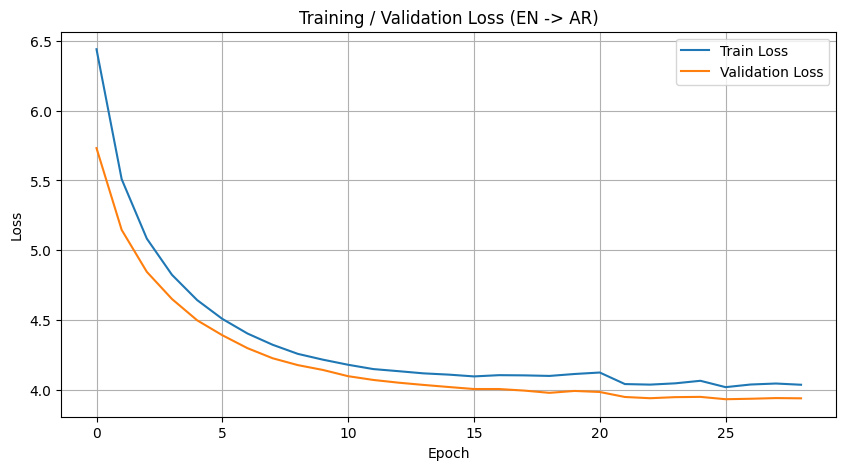

In [49]:
plt.figure(figsize=(10, 5))

plt.plot(history_en2ar["train"], label="Train Loss")
plt.plot(history_en2ar["val"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training / Validation Loss (EN -> AR)")

plt.legend()
plt.grid()

plt.show()


In [50]:
@torch.no_grad()
def translate_en2ar(model, english_sentence, max_len=30):

    model.eval()

    normalized = normalize_english(english_sentence)

    src_ids = src_vocab_en2ar.encode(normalized, add_sos=False, add_eos=True)

    src = torch.tensor([src_ids], dtype=torch.long, device=device)
    src_lens = torch.tensor([len(src_ids)], dtype=torch.long)
    src_mask = (src != Vocab.PAD)

    enc_outputs, hidden = model.encoder(src, src_lens)

    input_step = torch.tensor([Vocab.SOS], dtype=torch.long, device=device)

    generated = []

    for _ in range(max_len):

        logits, hidden, _ = model.decoder(input_step, hidden, enc_outputs, src_mask)

        pred = logits.argmax(-1).item()

        if pred == Vocab.EOS:
            break

        generated.append(pred)

        input_step = torch.tensor([pred], dtype=torch.long, device=device)

    return tgt_vocab_en2ar.decode(generated)


sample_en_sentences = [
    "He refused to pay.",
    "Human greed threatens the lives of many species.",
    "Law and politics are two different things.",
]

for s in sample_en_sentences:
    print("EN :", s)
    print("AR :", fix_arabic_display(translate_en2ar(model_en2ar, s)))
    print()


EN : He refused to pay.
AR : . ﻊﻓﺩ ﺾﻓﺭ ﺾﻓﺭ

EN : Human greed threatens the lives of many species.
AR : . ﻉﺍﻮﻧﻻﺍ ﻩﺎﻴﺣ ﺪﻳﺪﻬﺗ ﻥﺎﺴﻧﻻﺍ ﻥﺎﺴﻧﻻﺍ ﺩﺪﻬﺗ

EN : Law and politics are two different things.
AR : . ﻒﻠﺘﺨﻣ ﻥﺎﺌﻴﺷ ﺎﻤﻫ ﻪﺳﺎﻴﺴﻟﺍﻭ ﻥﻮﻧﺎﻘﻟﺍ



In [51]:
@torch.no_grad()
def evaluate_bleu_en2ar(model, dataset_path):

    references = []
    hypotheses = []

    with open(dataset_path, "r", encoding="utf-8") as f:

        for line in tqdm(f, desc="Translating Test Set (EN->AR)"):

            en, ar = line.rstrip("\n").split("\t")

            prediction = translate_en2ar(model, en)

            references.append(ar)
            hypotheses.append(prediction)

    bleu = sacrebleu.corpus_bleu(hypotheses, [references], tokenize="intl")

    return bleu, references, hypotheses


bleu_en2ar, refs_en2ar, hyps_en2ar = evaluate_bleu_en2ar(model_en2ar, EN2AR_TEST_FILE)
print(bleu_en2ar)


Translating Test Set (EN->AR): 0it [00:00, ?it/s]

That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


BLEU = 20.13 50.0/25.2/14.9/9.8 (BP = 0.972 ratio = 0.972 hyp_len = 27866 ref_len = 28658)


In [60]:
def detokenize_ar(text):
    text = re.sub(r"\s+([.,!?؟،])", r"\1", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


@torch.no_grad()
def beam_search_translate_en2ar(
    model,
    english_sentence,
    beam_width=5,
    max_len=30,
    length_penalty=0.7
):
    model.eval()

    normalized = normalize_english(english_sentence)
    src_ids = src_vocab_en2ar.encode(normalized, add_sos=False, add_eos=True)

    src = torch.tensor([src_ids], dtype=torch.long, device=device)
    src_lens = torch.tensor([len(src_ids)], dtype=torch.long)
    src_mask = (src != Vocab.PAD)

    enc_outputs, hidden = model.encoder(src, src_lens)

    # each beam: (token_id_sequence, cumulative_log_prob, hidden_state)
    beams = [([Vocab.SOS], 0.0, hidden)]
    completed = []

    for _ in range(max_len):
        candidates = []

        for seq, score, hid in beams:
            if seq[-1] == Vocab.EOS:
                completed.append((seq, score))
                continue

            input_step = torch.tensor([seq[-1]], dtype=torch.long, device=device)
            logits, hid_new, _ = model.decoder(input_step, hid, enc_outputs, src_mask)
            log_probs = torch.log_softmax(logits, dim=-1).squeeze(0)

            topk_log_probs, topk_ids = log_probs.topk(beam_width)

            for lp, idx in zip(topk_log_probs.tolist(), topk_ids.tolist()):
                candidates.append((seq + [idx], score + lp, hid_new))

        if not candidates:
            break

        candidates.sort(key=lambda b: b[1] / (len(b[0]) ** length_penalty), reverse=True)
        beams = candidates[:beam_width]

        if all(seq[-1] == Vocab.EOS for seq, _, _ in beams):
            completed.extend([(seq, score) for seq, score, _ in beams])
            break

    if not completed:
        completed = [(seq, score) for seq, score, _ in beams]

    best_seq, _ = max(completed, key=lambda x: x[1] / (len(x[0]) ** length_penalty))
    generated = [t for t in best_seq if t not in (Vocab.SOS, Vocab.EOS)]

    return tgt_vocab_en2ar.decode(generated)


@torch.no_grad()
def evaluate_beam_search_bleu_en2ar(model, dataset_path, beam_width=5):
    references = []
    hypotheses = []

    with open(dataset_path, "r", encoding="utf-8") as f:
        for line in tqdm(f, desc="Beam Search Translating (EN->AR)"):
            en, ar = line.rstrip("\n").split("\t")
            prediction = beam_search_translate_en2ar(model, en, beam_width=beam_width)

            references.append(detokenize_ar(ar))
            hypotheses.append(detokenize_ar(prediction))

    bleu = sacrebleu.corpus_bleu(hypotheses, [references], tokenize="intl")

    return bleu, references, hypotheses


beam_bleu_en2ar, refs_beam_en2ar, hyps_beam_en2ar = evaluate_beam_search_bleu_en2ar(
    model_en2ar, EN2AR_TEST_FILE, beam_width=5
)

print(f"Test BLEU (beam search, width=5): {beam_bleu_en2ar.score:.2f}")
print(f"Test BLEU (greedy, from earlier): {bleu_en2ar.score:.2f}")

Beam Search Translating (EN->AR): 0it [00:00, ?it/s]

Test BLEU (beam search, width=5): 21.16
Test BLEU (greedy, from earlier): 20.13


In [61]:
english_sentences_en2ar = []
with open(EN2AR_TEST_FILE, "r", encoding="utf-8") as f:
    for line in f:
        en, ar = line.rstrip("\n").split("\t")
        english_sentences_en2ar.append(en)

sentence_bleu_rows_en2ar = []
for en, ref, hyp in zip(english_sentences_en2ar, refs_beam_en2ar, hyps_beam_en2ar):
    score = sacrebleu.sentence_bleu(hyp, [ref], tokenize="intl").score
    sentence_bleu_rows_en2ar.append({
        "english": en,
        "reference": ref,
        "prediction": hyp,
        "bleu": score
    })

error_df_en2ar = pd.DataFrame(sentence_bleu_rows_en2ar)

top10_en2ar = error_df_en2ar.sort_values("bleu", ascending=False).head(10)

print("=== Top 10 Best Translations (beam search, highest sentence BLEU) ===\n")
for _, row in top10_en2ar.iterrows():
    print(f"EN : {row['english']}")
    print(f"REF: {row['reference']}")
    print(f"HYP: {row['prediction']}")
    print(f"BLEU: {row['bleu']:.2f}")
    print()

=== Top 10 Best Translations (beam search, highest sentence BLEU) ===

EN : wausau is a town in marathon county , wisconsin , united states .
REF: واوسو هي بلده تقع بولايه ويسكونسن في الولايات المتحده.
HYP: واوسو هي بلده تقع بولايه ويسكونسن في الولايات المتحده.
BLEU: 100.00

EN : lake county is a county located in the u . s . state of michigan .
REF: مقاطعه ليك هي احدي مقاطعات ولايه ميشيغان في الولايات المتحده.
HYP: مقاطعه ليك هي احدي مقاطعات ولايه ميشيغان في الولايات المتحده.
BLEU: 100.00

EN : 254 255 .
REF: 254 – 255.
HYP: 254 – 255.
BLEU: 100.00

EN : spring grove is a city in houston county , minnesota , united states .
REF: سبرينغ غروف هي مدينه تقع في ولايه مينيسوتا في الولايات المتحده.
HYP: سبرينغ غروف هي مدينه تقع في ولايه مينيسوتا في الولايات المتحده.
BLEU: 100.00

EN : the population was 2 , 060 at the 2010 census .
REF: يقدر عدد سكانها ب 2, 060 نسمه.
HYP: يقدر عدد سكانها ب 2, 060 نسمه.
BLEU: 100.00

EN : me too .
REF: انا ايضا.
HYP: انا ايضا.
BLEU: 100.00

EN : where is the 

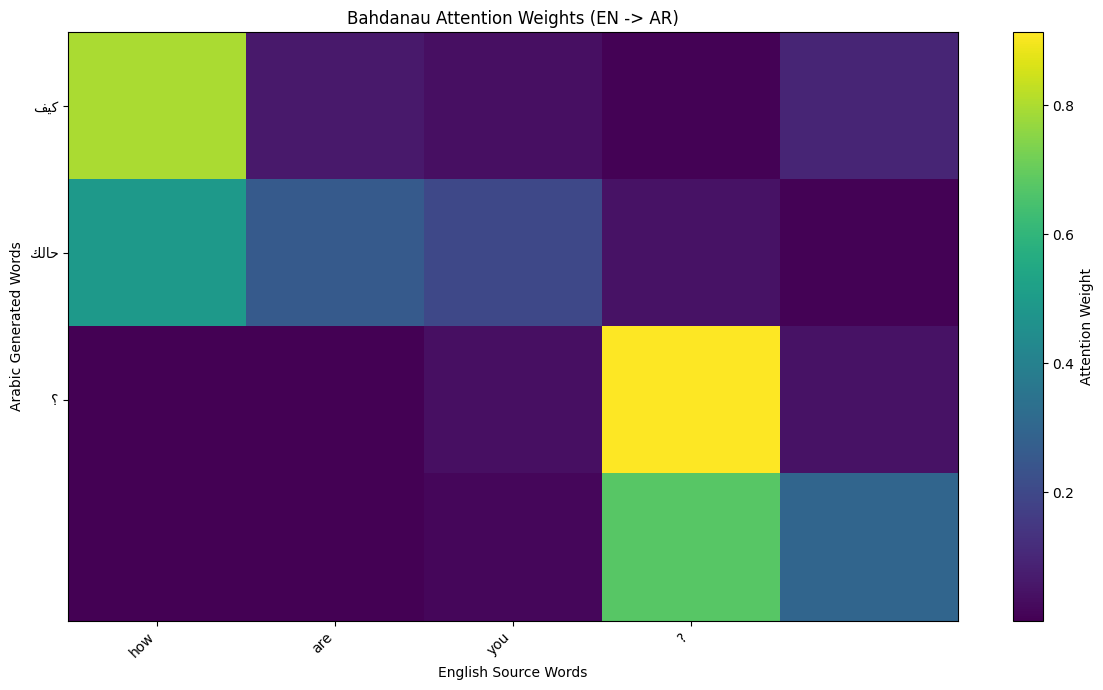

English: how are you ?
Arabic : ؟ ﻚﻟﺎﺣ ﻒﻴﻛ


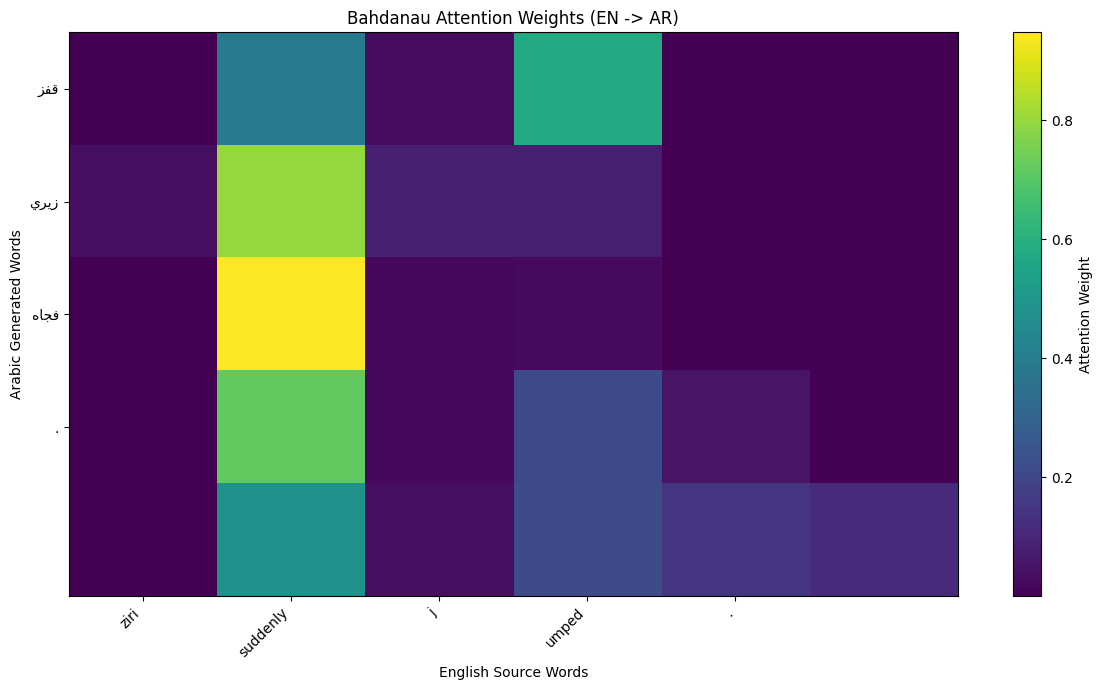

English: ziri suddenly jumped .
Arabic : . ﻩﺎﺠﻓ ﻱﺮﻳﺯ ﺰﻔﻗ


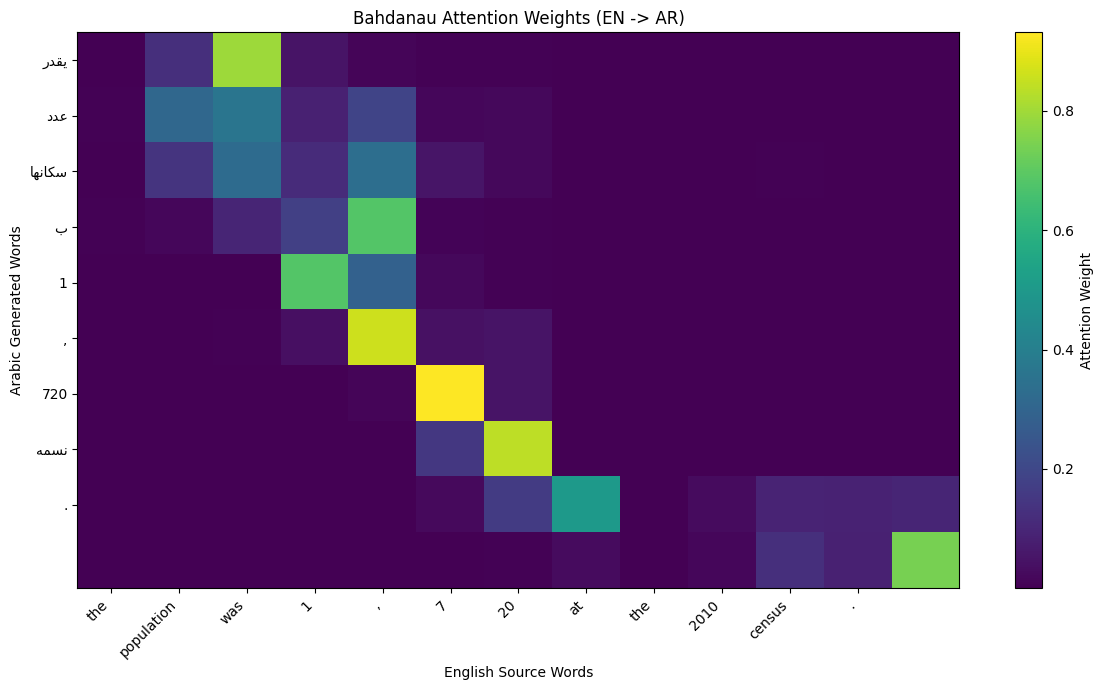

English: the population was 1 , 720 at the 2010 census .
Arabic : . ﻪﻤﺴﻧ 720 , 1 ﺏ ﺎﻬﻧﺎﻜﺳ ﺩﺪﻋ ﺭﺪﻘﻳ


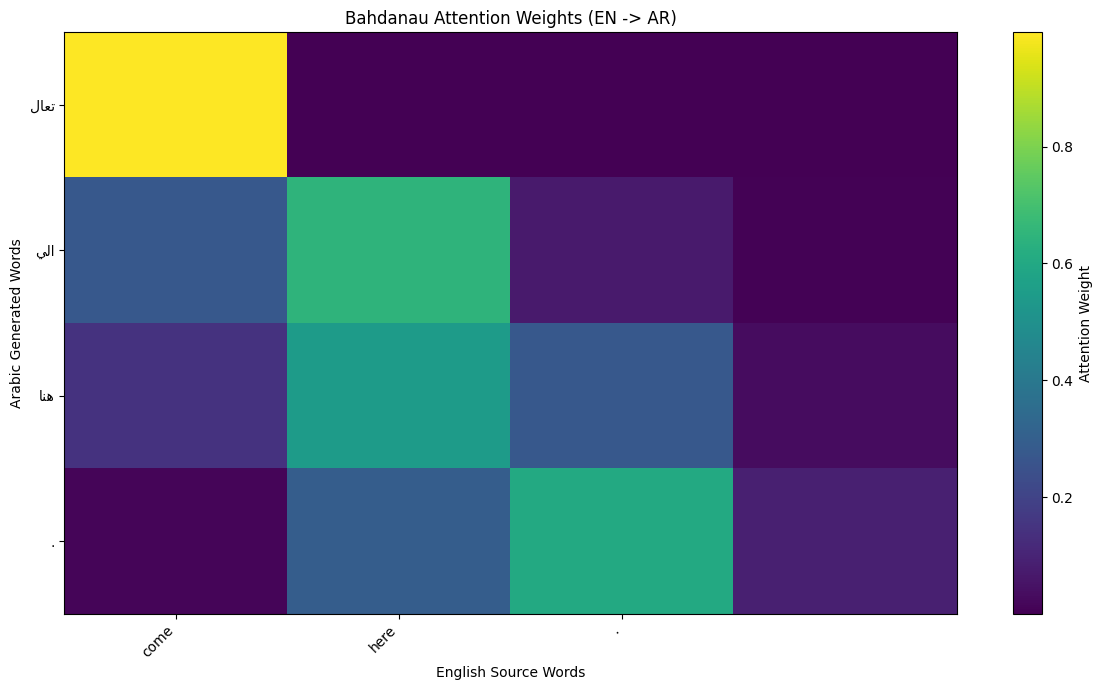

English: come here .
Arabic : . ﺎﻨﻫ ﻲﻟﺍ ﻝﺎﻌﺗ


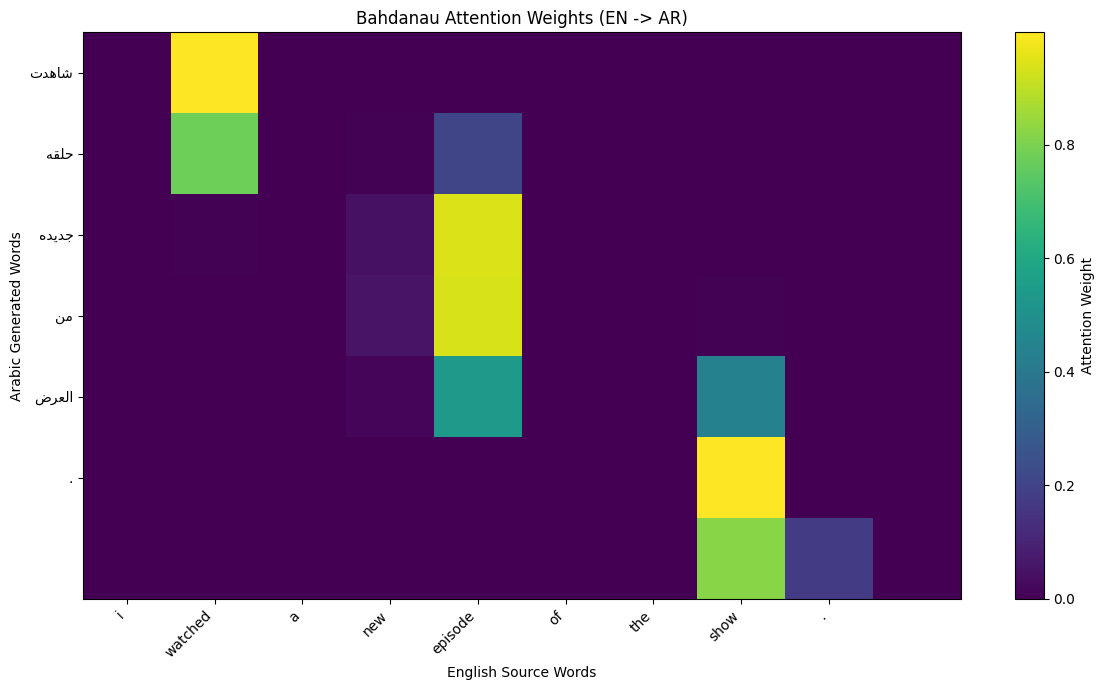

English: i watched a new episode of the show .
Arabic : . ﺽﺮﻌﻟﺍ ﻦﻣ ﻩﺪﻳﺪﺟ ﻪﻘﻠﺣ ﺕﺪﻫﺎﺷ


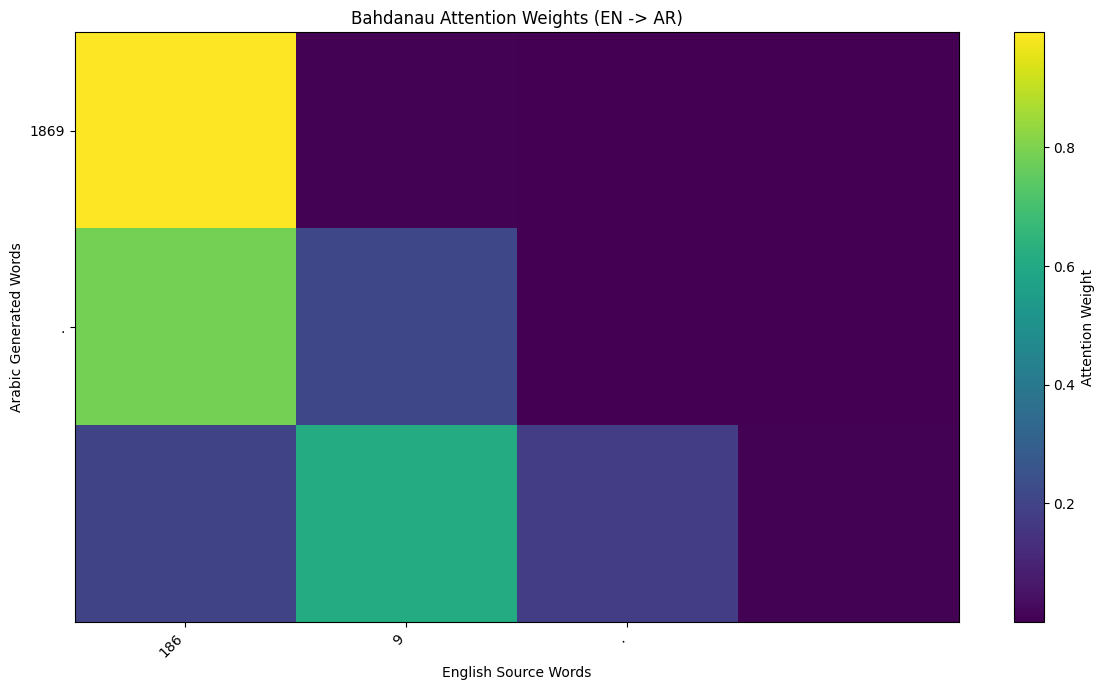

English: 1869 .
Arabic : 1869 .


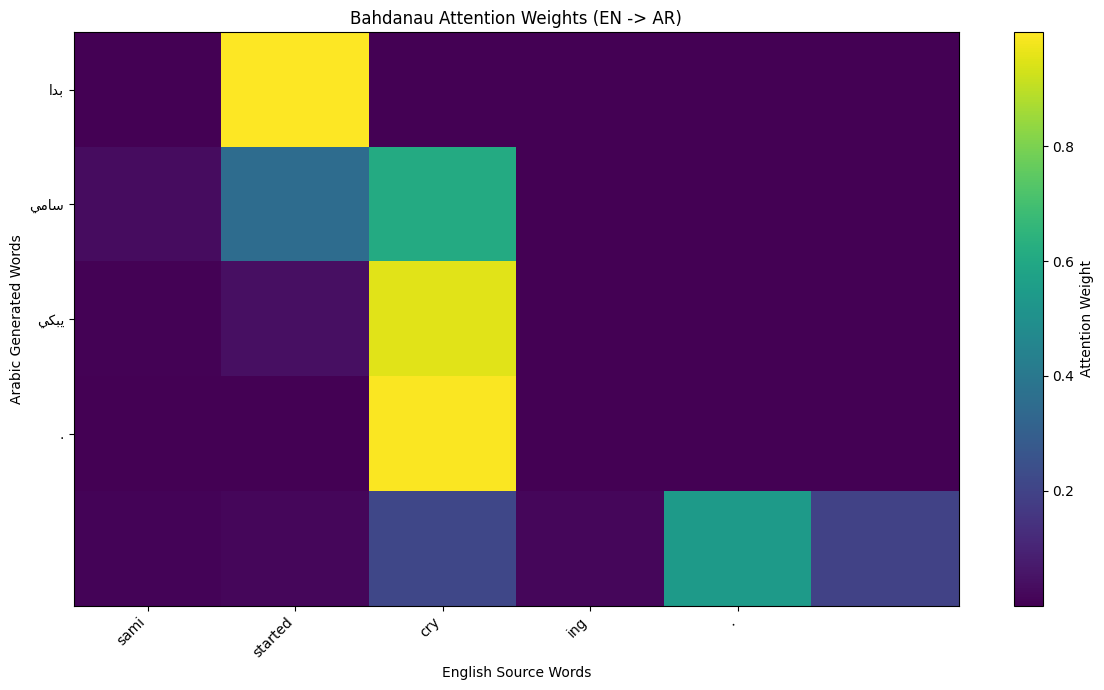

English: sami started crying .
Arabic : . ﻲﻜﺒﻳ ﻲﻣﺎﺳ ﺍﺪﺑ


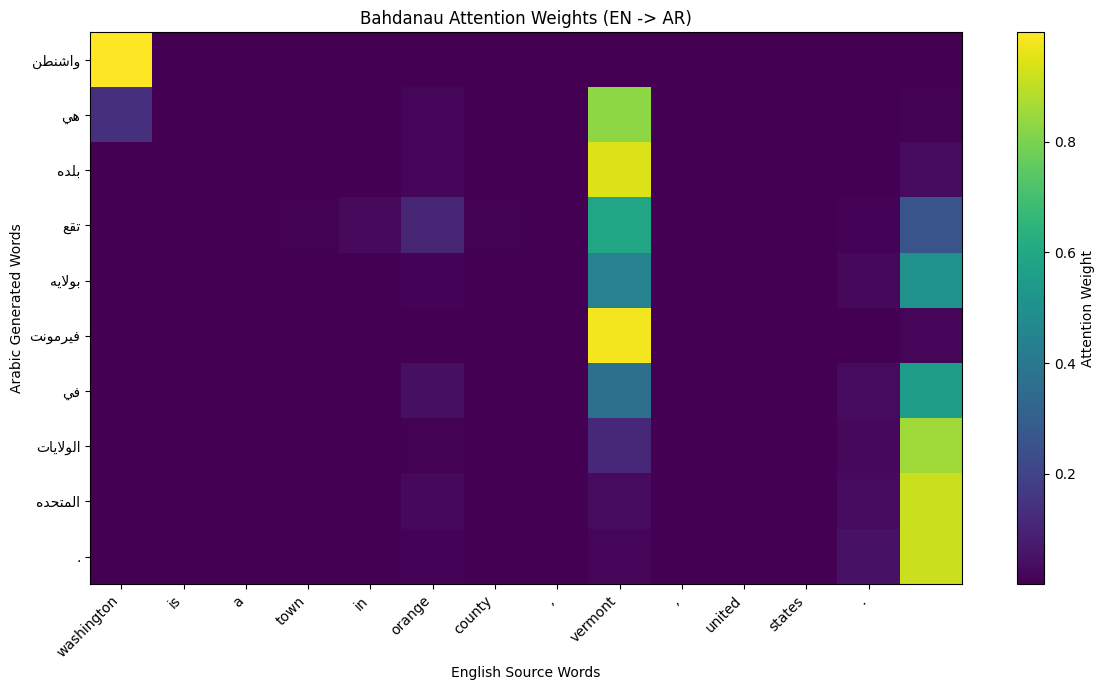

English: washington is a town in orange county , vermont , united states .
Arabic : . ﻩﺪﺤﺘﻤﻟﺍ ﺕﺎﻳﻻﻮﻟﺍ ﻲﻓ ﺖﻧﻮﻣﺮﻴﻓ ﻪﻳﻻﻮﺑ ﻊﻘﺗ ﻩﺪﻠﺑ ﻲﻫ ﻦﻄﻨﺷﺍﻭ


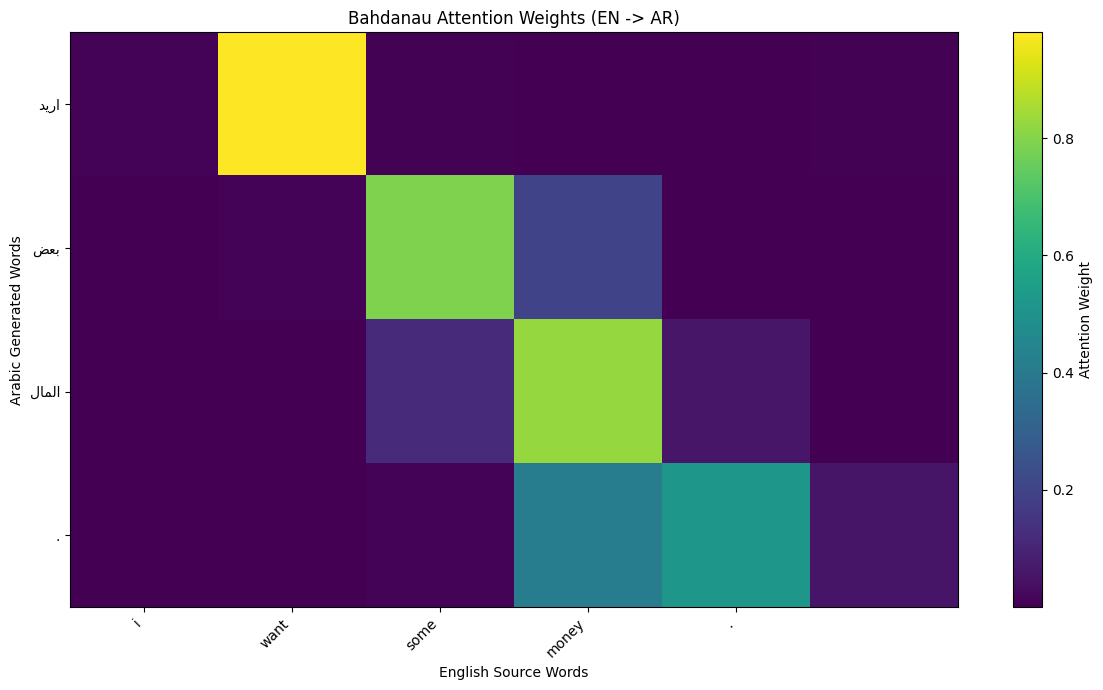

English: i want some money .
Arabic : . ﻝﺎﻤﻟﺍ ﺾﻌﺑ ﺪﻳﺭﺍ


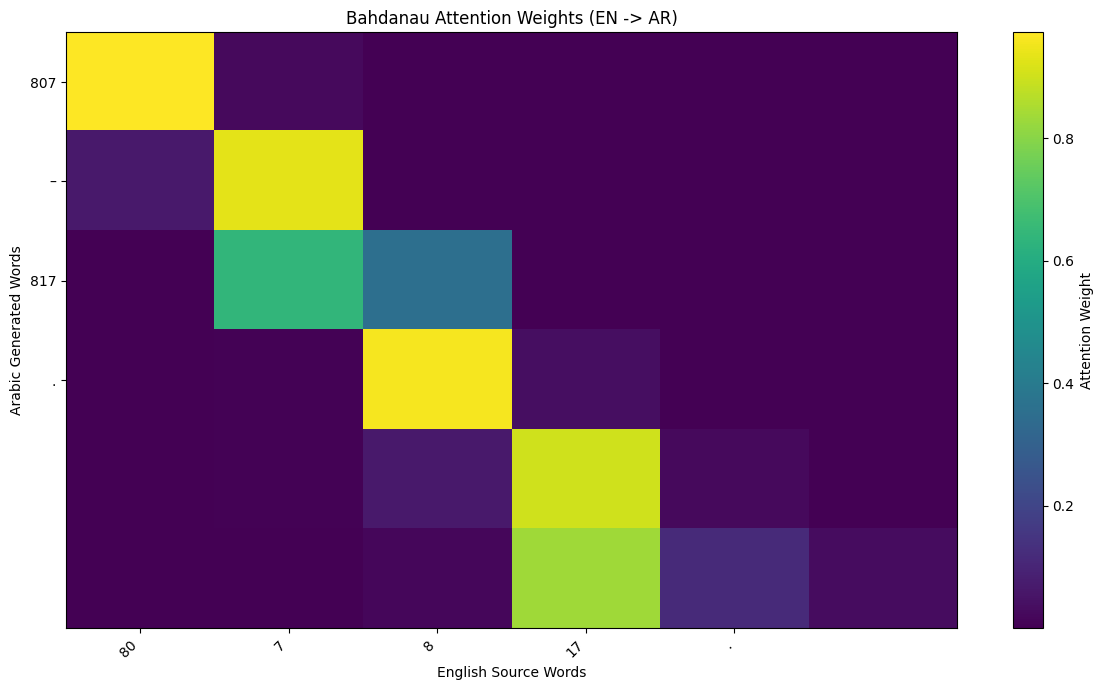

English: 807 817 .
Arabic : 807 – 817 .


In [59]:
@torch.no_grad()
def translate_en2ar_with_attention(model, english_sentence, max_len=30):
    model.eval()

    normalized = normalize_english(english_sentence)
    src_ids = src_vocab_en2ar.encode(normalized, add_sos=False, add_eos=True)

    tokens = [
        piece.replace("\u2581", " ").strip()
        for piece in src_vocab_en2ar.encode_pieces(normalized)
    ]

    src = torch.tensor([src_ids], dtype=torch.long, device=device)
    src_lens = torch.tensor([len(src_ids)], dtype=torch.long)
    src_mask = (src != Vocab.PAD)

    enc_outputs, hidden = model.encoder(src, src_lens)

    input_step = torch.tensor([Vocab.SOS], dtype=torch.long, device=device)

    generated = []
    attention_weights = []

    for _ in range(max_len):
        logits, hidden, attn = model.decoder(input_step, hidden, enc_outputs, src_mask)
        pred = logits.argmax(-1).item()

        if pred == Vocab.EOS:
            break

        generated.append(pred)
        attention_weights.append(attn[0].cpu().numpy())

        input_step = torch.tensor([pred], dtype=torch.long, device=device)

    translation = tgt_vocab_en2ar.decode(generated)

    return translation, np.array(attention_weights), tokens


def show_attention_en2ar(english_sentence):
    translation, attention, src_tokens = translate_en2ar_with_attention(
        model_en2ar, english_sentence
    )

    tgt_tokens = translation.split()

    plt.figure(figsize=(12, 7))
    plt.imshow(attention, aspect="auto")

    plt.xticks(range(len(src_tokens)), src_tokens, rotation=45, ha="right")

    fixed_tgt_tokens = [fix_arabic_display(tok) for tok in tgt_tokens]
    plt.yticks(range(len(fixed_tgt_tokens)), fixed_tgt_tokens)

    plt.xlabel("English Source Words")
    plt.ylabel("Arabic Generated Words")
    plt.title("Bahdanau Attention Weights (EN -> AR)")

    plt.colorbar(label="Attention Weight")
    plt.tight_layout()
    plt.show()

    print("English:", english_sentence)
    print("Arabic :", fix_arabic_display(translation))


for sent in top10_en2ar["english"]:
    show_attention_en2ar(sent)

## Save the English → Arabic Model

In [52]:
SAVE_DIR_EN2AR = f"{WORK_DIR_EN2AR}/en2ar_saved"
os.makedirs(SAVE_DIR_EN2AR, exist_ok=True)

torch.save({
    "direction": "en2ar",
    "model_state_dict": model_en2ar.state_dict(),
    "encoder_hparams": dict(
        vocab_size=len(src_vocab_en2ar),
        embed_dim=EMBED_DIM,
        enc_hidden=ENC_HIDDEN,
        dec_hidden=DEC_HIDDEN,
        dropout=DROPOUT,
    ),
    "decoder_hparams": dict(
        vocab_size=len(tgt_vocab_en2ar),
        embed_dim=EMBED_DIM,
        enc_hidden=ENC_HIDDEN,
        dec_hidden=DEC_HIDDEN,
        attn_dim=ATTN_DIM,
        dropout=DROPOUT,
    ),
}, f"{SAVE_DIR_EN2AR}/en2ar_model.pt")

for fname in ["spm_en.model", "spm_en.vocab", "spm_ar.model", "spm_ar.vocab"]:
    shutil.copy(f"{SPM_DIR}/{fname}", f"{SAVE_DIR_EN2AR}/{fname}")

shutil.make_archive(f"{WORK_DIR}/en2ar_bundle", "zip", SAVE_DIR_EN2AR)
print("Saved English -> Arabic model bundle to:", f"{WORK_DIR}/en2ar_bundle.zip")



Saved English -> Arabic model bundle to: /kaggle/working/nmt_project/en2ar_bundle.zip
